# Everyone Watches Women’s Basketball: Attendance and Fan Engagement in

the WNBA

Gabriela Eastwood ([Smith College](https://www.smith.edu/))  
[Benjamin S. Baumer](https://www.smith.edu/people/ben-baumer) [](https://orcid.org/0000-0002-3279-0516) ([Smith College](https://www.smith.edu/))  
[Andrew Zimbalist](https://www.smith.edu/people/andrew-zimbalist) ([Smith College](https://www.smith.edu/))  
July 6, 2026

We examine how the relationships between attendance and three notions of fan engagement have changed over the history of the WNBA. Previous research suggests that stronger professional sports teams draw higher live game attendance. However, there is ongoing doubt about the extent to which that relationship holds in the WNBA. We improve upon previous research by modeling attendance in the broader context of the league’s growth from 1997-2025, and find that the factors that drive fan demand have evolved as the league has matured. We test whether three leading theories of fan behavior—quality of play, loss aversion, and outcome uncertainty—have become more important drivers of attendance as the league has grown. We use game-level attendance data reported directly by the WNBA as well as team Elo ratings and game-by-game home win probabilities and find that in recent years fans are increasingly likely to attend games in response to quality of play and loss aversion factors. We also find strong support for the large impact of Indiana Fever guard Caitlin Clark’s presence upon attendance. Our results suggest that the WNBA is entering a new era in which fans are choosing to attend games to watch good basketball rather than novelty-driven interest or broader support for women’s sports.

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

In [ ]:
manual <- c("ggplot2", "tidycensus", "sandwich", "elo", "VGAM")
pkgs <- unique(c(manual, .packages()))
knitr::write_bib(pkgs, file = "pkgs.bib")

In [ ]:
wnba_gl <- read_rds(here::here("data/wnba_gl.rds")) |>
  group_by(arena) |>
  mutate(
    median_income = median_income / 1000,
    metro_pop = total_pop / 1000000,
    est_capacity = max(max(attendance), arena_capacity),
    pct_capacity = attendance / est_capacity,
    pct_capacity_safe = case_when(
      pct_capacity == 1 ~ 0.999, 
      pct_capacity == 0 ~ 0.001,
      TRUE ~ pct_capacity
    ),
    arena_size = case_when(
      arena_capacity >= 16000 ~ "arena_large",
      arena_capacity >= 11000 ~ "arena_medium",
      arena_capacity >= 5500 ~ "arena_small",
      TRUE ~ "arena_unknown"
    )
  ) |>
  ungroup() |>
  mutate(
    is_sellout = pct_capacity > 0.92,
    quality_of_play = elo_home_pregame * elo_away_pregame,
    uncertain_outcome = -sqrt(abs(elo_home_pregame - elo_away_pregame)),
    loss_aversion = elo_home_win_prob^2,
    z1_quality_of_play = (quality_of_play - mean(quality_of_play)) / sd(quality_of_play), 
    z2_uncertain_outcome = (uncertain_outcome - mean(uncertain_outcome)) / sd(uncertain_outcome),
    z3_loss_aversion = (loss_aversion - mean(loss_aversion)) / sd(loss_aversion),
    zzz_sum_all_three = z3_loss_aversion + z1_quality_of_play + z2_uncertain_outcome,
  ) |>
  ungroup()

In [ ]:
ggplot(wnba_gl, aes(x = uncertain_outcome)) +
  geom_histogram() +
  scale_color_viridis_c()
ggplot(wnba_gl, aes(x = z2_uncertain_outcome)) +
  geom_histogram() +
  scale_color_viridis_c()
ggplot(wnba_gl, aes(x = elo_home_pregame, y = elo_away_pregame, color = z2_uncertain_outcome)) +
  geom_point() +
  scale_color_viridis_c()

ggplot(wnba_gl, aes(x = pct_capacity, y = pct_capacity_safe)) +
  geom_point()

wnba_gl |>
  filter(pct_capacity != pct_capacity_safe)

## Introduction

In the years prior to the 2020 WNBA collective bargaining agreement (CBA), NBA Commissioner Adam Silver publicly characterized the women’s league as unpopular and unprofitable \[@garcia2020betting\]. Again during the CBA renegotiations in 2025, NBA and WNBA leadership made similar negative claims about the women’s league’s long term viability. While leadership has been ironically pessimistic about the health of the WNBA in recent years, their claims stand in tension with recent trends: the league has enjoyed a significant increase in attendance and fan interest in the past several seasons.

While this trend is encouraging for anyone interested in the success of the WNBA, further breaking down the underlying components of this trend is necessary both to explain and sustain this growth. For decades, league officials and sports economists have debated the primary drivers of game attendance, identifying game-related and market-related factors impacting fan interest and game attendance. Much of this research, beginning with foundational work in the 1970s, assumes that fans are more likely to attend games when the home team is expected to do well. This relationship is widely tested and supported in men’s professional sports, but women’s leagues and the WNBA in particular are still largely underresearched. As a relatively young league with rapid growth in viewership \[@wnba2024recordseason\] but limited publicly available financial data, game attendance remains the most readily available proxy for public interest in the WNBA. In this paper we set out to determine how the underlying causes shape game attendance and explain these more recent trends. Specifically, we focus on whether on-court factors are becoming more important to WNBA game attendance in recent years.

### Existing scholarship on team performance and game attendance

A key line of research in sports economics links fan demand to expectations about game outcomes. Early work such as the uncertainty-of-outcome hypothesis suggests that attendance is higher when game results are less predictable, increasing perceived excitement.

> **Ben**
>
> We need a citation for the Uncertainty of Outcome Hypothesis

@CoatesHumphreysZhou2014 use more recent behavioral economics models to suggest that people evaluate gains and losses relative to a reference point and tend to dislike losses more than they like equivalent wins. They argue that applying this idea of loss aversion may better explain why fans choose to go games than the uncertainty of outcome hypothesis. They use MLB live-game attendance data to find patterns consistent with the hypothesis that fans are less likely to attend games in which they expect the home team to lose \[@CoatesHumphreysZhou2014\]. These frameworks together suggest that attendance decisions are sensitive not only to team quality, but to expectations about competitive performance and likely game outcomes.

> **Ben**
>
> Let’s say more about expected utility and non-linearity

In the first study in sports economics that sought to empirically identify the factors that affected attendance, @noll1974attendance considered data from MLB, the NFL, NHL, NBA and ABA (American Basketball Association) for the 1969-70 and 1970-71 seasons and found that demand was a function of population, interactions of income with star players, team win percentage, and per capita income. Multiple subsequent studies on men’s professional team sports continued to find a statistically significant correlation between team quality and attendance. Differences in the literature over how to measure team quality (wins, wins lagged, number of championships in past years, win probability, star power), attendance (logs, lags, linear regression or censored), the inclusion of control variables and non-linear forms also emerged \[@wiseman2003team; @woltring2018attendance; @kim2023winning; @deschriver2002determinants; @paul2019attendance\].

The relationship between attendance and winning percentage has been examined, but such studies often look at winning percentage as causation for attendance.

> **Ben**
>
> Winning percentage *is* a measure of team strength. So how is this different than what we’re saying above?

@davis2008interaction and @horowitz2007if both found that attendance and winning percentage were related. Horowitz concluded a bidirectional relationship between the two, while Davis suggested that causation runs from winning percentage to attendance. In a following study, @davis2009analyzing found winning percentage as a significant determinant of attendance for 12 National League teams; though the study did not establish causation both ways. @lemke2010estimating found attendance increases as home team win probability increases. There is evidence that causation may run from attendance to winning percentage, but the bulk of the literature has been researched the other way.

> **Ben**
>
> What evidence? We should cite something if there is evidence.
>
> Also, really? Attedance causes winning percentage to rise???

Finally, situating these revenue models within the broader league structure, sports economists have written extensively about the relationship between winningness and team revenue, particularly about how competitive balance benefits teams across the league in generating revenue.

> **Ben**
>
> What revenue models??

While teams and fans want to win as many games as possible, significant imbalance in winning percentages across a professional sports league will tend to decrease viewership as spectators will only watch a game if they have some uncertainty about the outcome \[@PerlineNobleStoldt2018\]. In NCAA basketball, @PerlineNobleStoldt2018 examine the standard deviation and the range of winning percentages for teams in the women’s Division I and determine that the women’s game os significantly less balanced than the men’s game. They hypothesize that the difference in the competitive balance of the men’s and women’s games could be one cause of lower revenue generation and attendance in the women’s game.

### Why is the WNBA different?

@AghaBerri2023 argue that a major reason why attendance is considerably lower at WNBA games relative to NBA games is that the women’s league is still in its early years, only beginning play in 1997 compared to the NBA’s 1946. To account for this, they compare attendance in the tenth season of the WNBA (2006) and the NBA (1955/56) (p. 36). In their respective tenth years, the WNBA average attendance per home game exceeded the NBA’s by more than 2,000 fans per game. This comparison suggests that the current disparity in attendance between the women’s and men’s league should not be interpreted as a lack of demand, but rather a sign of the league’s maturity. Considering the league’s age as a factor in demand for attendance, we inquire further into whether patterns of fan behavior change as the league matures. @AghaBerri2023 attempt to establish whether different forces shape demand for attendance in the WNBA and the NBA, finding that team performance was not a statistically significant predictor of game attendance in the WNBA. As noted above, this is contrary to the virtually unanimous finding in the existing scholarship for men’s leagues. However, their study only employed data from 2004 through 2017 and thus cannot capture the more recent improvements in attendance shown in @fig-boxplots. They also measure a team’s strength using the team’s winning percentage from the previous year which raises issues because fans are more likely to respond to the more recent performance of the team. Thus, while a team’s win percentage in 2016 might have an appreciable impact on the team’s attendance at the beginning of the 2017 season, as the season wears on, this impact should diminish.

The disparity between raw attendance numbers and attendance driving factors in the NBA and WNBA cannot be attributed to the age of the leagues alone. Additional important factors include: the WNBA plays during the summer months in order to promote arena use outside of the NBA season; there is less money spent on promotion; reduced media coverage; historical prejudice; poorer arena amenities and age; and ticket prices, among others.

> **Ben**
>
> Why would ticket prices decrease attendance? Aren’t they lower in the WNBA?

Sport management literature also includes several studies that find a major motivation behind fandom for women’s sports leagues to be an area’s overall support for feminist issues, suggesting that fans in those areas may attend games out of political support rather than to see good basketball \[@delia2020psychological; @guest2018fan; @leslie2022football\]. Factors like the summer season, reduced media coverage, and the association of game attendance with feminist causes all contribute to the argument that the WNBA functions fundamentally differently to the NBA—at least in terms of attendance drivers. This conception of the WNBA as fundamentally different from the NBA is dangerous both to the league’s reputation and future growth, motivating our more thorough examination of game attendance in the context of the league’s history.

### Our contribution

It is reasonable to anticipate that as women’s sports mature and are perceived increasingly as a normal sports league (rather than a political concession or oddity) they will begin to assert similar fan demand characteristics. In particular, fan demand should become more responsive to team quality. Using game attendance and team performance data from 1997 through 2025, we test these hypotheses. In viewing more recent attendance figures for the WNBA in the context of the league’s history, we determine whether predictors of attendance have shifted over time. Specifically, we find that in recent years the strength of the effect of a game’s uncertainty, the strength of both teams, and the likelihood of a home team win, on game attendance has increased, paralleling documented trends in men’s leagues.

## Data

### Game logs

Our analysis is based on game-level data that spans WNBA history, beginning in 1997 and continuing through the end of the 2025 season. Our final data set contains observations from 6,164 games.

First, we collected game-level attendance data from \[@AcrossTheTimeline\], an online repository for women’s basketball data that collects attendance numbers directly from the league’s records[1]. Attendance data was unavailable for only 152 games, while (due to the COVID-19 pandemic) 2 games (accurately) recorded attendance of 0. The arenas in which WNBA teams play vary widely in size. The New York Liberty alone have called both the Barclays Center (17,732 seat capacity) and the Westchester County Center (2,300 seat capacity) home in recent years. While teams have many reasons they might choose to play for a sold-out crowd in a smaller arena, smaller venue size will also by nature constrain attendance, making its consideration in our model important.

Second, we collected game-level performance data from the **wehoop** R package \[@hutchinson_gilani_2021_wehoop\], which uses the official WNBA API. These data include the final score of the game, among other performance metrics. We also used the **wehoop** package to identify whether Caitlin Clark and/or A’ja Wilson played more than 0 minutes in the game.

@tbl-attendance shows a sample of the data. While many other variables are omitted from the table, we note that the attendance, the teams playing in the game, the outcome, the arena, and whether Clark or Wilson played in the game are recorded.

[1] Note that, as in most sports leagues, there is always the possibility of finagling with game attendance figures. The WNBA appears to give attendance counting instructions to teams that define attendance as tickets out, including total ticket sales, plus complimentary tickets and promotions. There is considerable room for these factors to be manipulated, rendering the possibility of noise in the attendance figures we use.

In [ ]:
wnba_gl |>
  select(
    game_date,
    home = team_abbreviation,
    away = opponent,
    arena,
    attendance,
    plus_minus,
    clark = is_cc,
    wilson = is_aw
  ) |>
  slice_sample(n = 10) |>
  janitor::clean_names(case = "title") |>
  gt() |>
  tab_header(
    title = "WNBA Game Data (1997-2025)",
    subtitle = "Sample of game-level records"
  ) |>
  fmt_number(
    columns = Attendance,
    decimals = 0
  ) |>
  tab_options(
    table.font.size = px(11),
    table.width = pct(100)
  )

### Attendance

@fig-boxplots shows the distribution of attendance across all seasons, with a logarithmic scale on the vertical axis. There is no attendance data from 2020, because all games that year were played in the WNBA bubble due to the COVID-19 pandemic, and some games in 2021 were played with artificially low attendance.

In [ ]:
wnba_summary <- wnba_gl |>
  group_by(season_id) |>
  summarize(
    num_games = n(),
    avg_attendance = mean(attendance)
  )

attend_hi <- max(wnba_summary$avg_attendance, na.rm = TRUE)
attend_prev_hi <- min(tail(sort(wnba_summary$avg_attendance), 2))
attend_pct_increase <- 100 * (attend_hi / attend_prev_hi - 1)

Several broad observations can be made from @fig-boxplots. First, after some initial enthusiasm during the first three years of the league, attendance largely plateaued or steadily but slightly declined from 2000 to 2017. \[Note that @AghaBerri2023 used only data through 2017.\] The two years preceding the pandemic (2018-2019) had notably lower attendance. However, since the pandemic, attendance has rebounded, exceeding its initial levels in 2024 and reaching new heights in 2025. In fact, average WNBA attendance in 2025 was 10,986, which was 1.1% higher than the previous high in 1998.

These last two years coincide with the arrival of Caitlin Clark, the 2024 Rookie of the Year Award winner who is widely regarded as a generational talent. Disentangling the “Caitlin Clark effect” from the league’s overall attendance trends is one of our goals. To that end, we identified all games in which Clark and A’ja Wilson played. Wilson is a four-time WNBA MVP and three-time league champion who is currently viewed as the league’s best player. As a superior played with less celebrity, Wilson’s effect on attendance relative to Clark’s provides additional benchmarking possibilities.

Warning in scale_y_log10(): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

(`stat_boxplot()`).

(`geom_point()`).

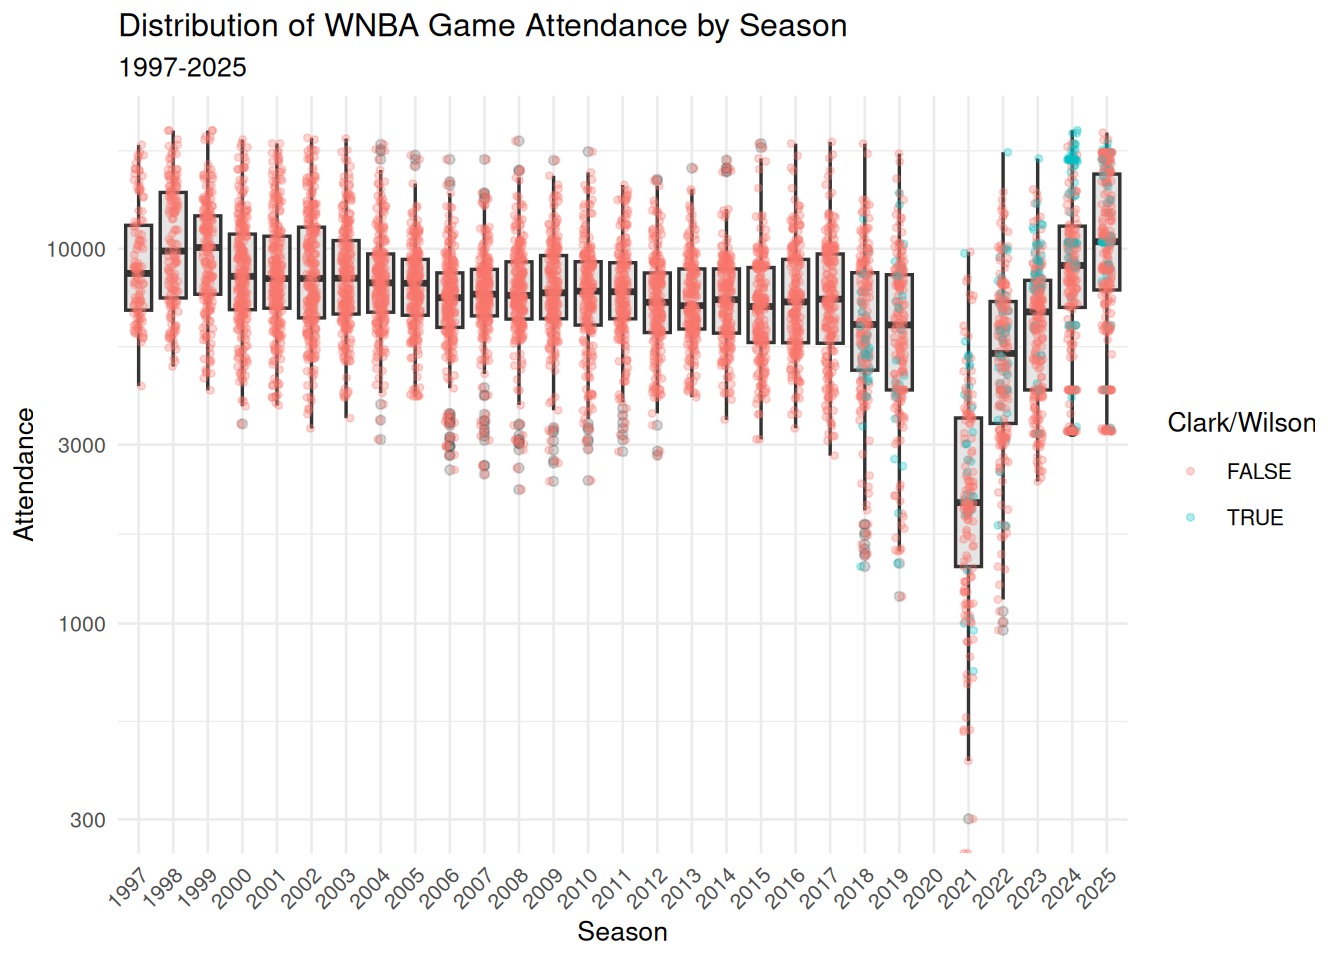

In [ ]:
plot_attend_eda <- ggplot(wnba_gl, aes(x = factor(season_id), y = attendance)) +
  geom_boxplot(outlier.alpha = 0.2, linewidth = 0.6, fill = "grey90") +
  geom_jitter(alpha = 0.3, width = 0.15, size = 1, aes(color = factor(is_cc | is_aw))) +
  labs(
    title = "Distribution of WNBA Game Attendance by Season",
    subtitle = "1997-2025",
    x = "Season",
    y = "Attendance"
  ) +
  scale_color_discrete(name = "Clark/Wilson") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
plot_attend_eda +
  scale_y_log10()

### Arena capacity

While we recorded reported arena capacities, those capacities were difficult to obtain for venues not in current use, they change over time, and some games had attendance that exceeded the arena’s reported capacity. Thus, we estimate each arena’s capacity as the larger of the reported capacity, or the maximum recorded attendance at that arena in the sample. This ensures that our figures for the percentage of estimated arena capacity are bounded above by 1.

We designate a sellout as a game in which the attendance exceeds 92% of the arena’s estimated capacity. Using our definition, we deem 3.5% of the games to be sellouts, with nearly half of those occurring in the past two seasons. 38 of Clark’s 53 games have sold out.

@fig-boxplots-capacity shows the distribution of attendance as a percentage of the arena’s estimated capacity.

(`stat_boxplot()`).

(`geom_point()`).

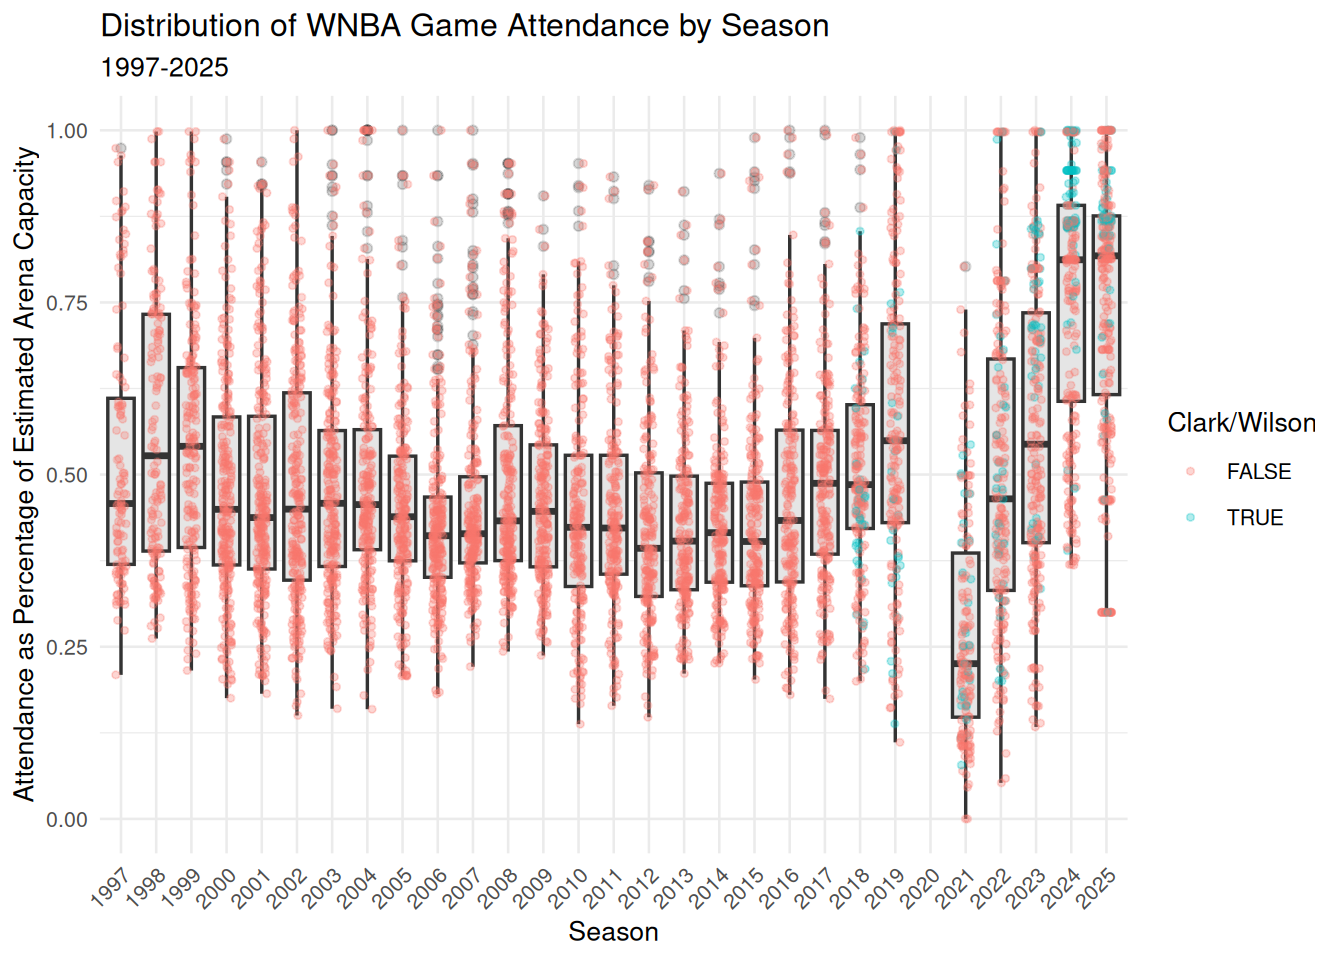

In [ ]:
plot_attend_eda +
  aes(y = pct_capacity) +
  scale_y_continuous("Attendance as Percentage of Estimated Arena Capacity")

### Estimating team strength

We used the game-level results data to model the evolution of the strength of each WNBA team over time. Measuring team strength is necessary to test our hypothesis that attendance is in part driven by the desire of fans to see quality basketball. We considered season-to-date winning percentage and a rolling 44-game (the length of a typical WNBA season) winning percentage before settling on Elo rating \[@Elo1978\], because Elo rating updates with each game, and thus more accurately reflects the information that fans have access to in deciding to attend games. Originally developed for rating chess players, Elo rating is well-understood in sports analytics as a measure of team strength that updates after each game, and—unlike winning percentage and rolling winning percentage—takes into account not only the outcome but also the previous estimated team strength of both teams. This means that beating a team with a higher Elo rating has a greater positive effect than beating a team with a lower Elo rating, imbuing outcomes with more nuance than simple win-loss record.

Let $\theta_{i}(t)$ be the strength of team $i$ at time $t$, where Elo ratings are centered at 1500. Then if the probability that team $i$ beats team $j$ is modeled by a logistic curve with base 10 and scale factor 400, the win probability is given by:
$$p_{ij}(t) = \Pr(i \text{ beats }j \text{ at time }t) = \frac{1}{1 + 10^{\frac{\theta_{j}(t) -  \theta_{i}(t)  }{400}}} \,.$$

Each team $i$ starts the 1997 season with $\hat{\theta}_{i}(0) = 1500$, and following each game, team $i$’s rating is updated via the formula
$$  \hat{\theta}_{i}(t+1) = \hat{\theta}_{i}(t) + K \cdot \left[ I(i \text{ beats } j)  - \hat{p}_{ij}(t) \right] $$
where $I(i \text{ beats } j)$ is an indicator variable that is 1 if $i$ beats $j$ and $-1$ if $j$ beats $i$, and $K = 32$ is a constant that controls how sensitive the ratings are to each game. For example, suppose team $i$ has an Elo rating of 1600 and team $j$ 1450. Then team $i$ has a 0.703 probability of beating team $j$ and if they win, their rating will improve by $32 \cdot (1 - \text{0.703}) = \text{9.49}$ points, while team $j$’s rating will decrease by the same amount. Note that if team $j$ upsets team $i$, the corresponding changes in rating will be 22.51 points. This larger amount reflects the less likely outcome.

We fit Elo ratings using the **elo** \[@R-elo\] package for R. @fig-elo shows the evolution of Elo rating $\hat{\theta}_i(t)$ by franchise for the 12 teams who were active during the 2024 season. The recent poor performance of the Los Angeles Sparks, the 2010 dominance of the Seattle Storm, and the recent rise of the New York Liberty and Indiana Fever are easily visible.

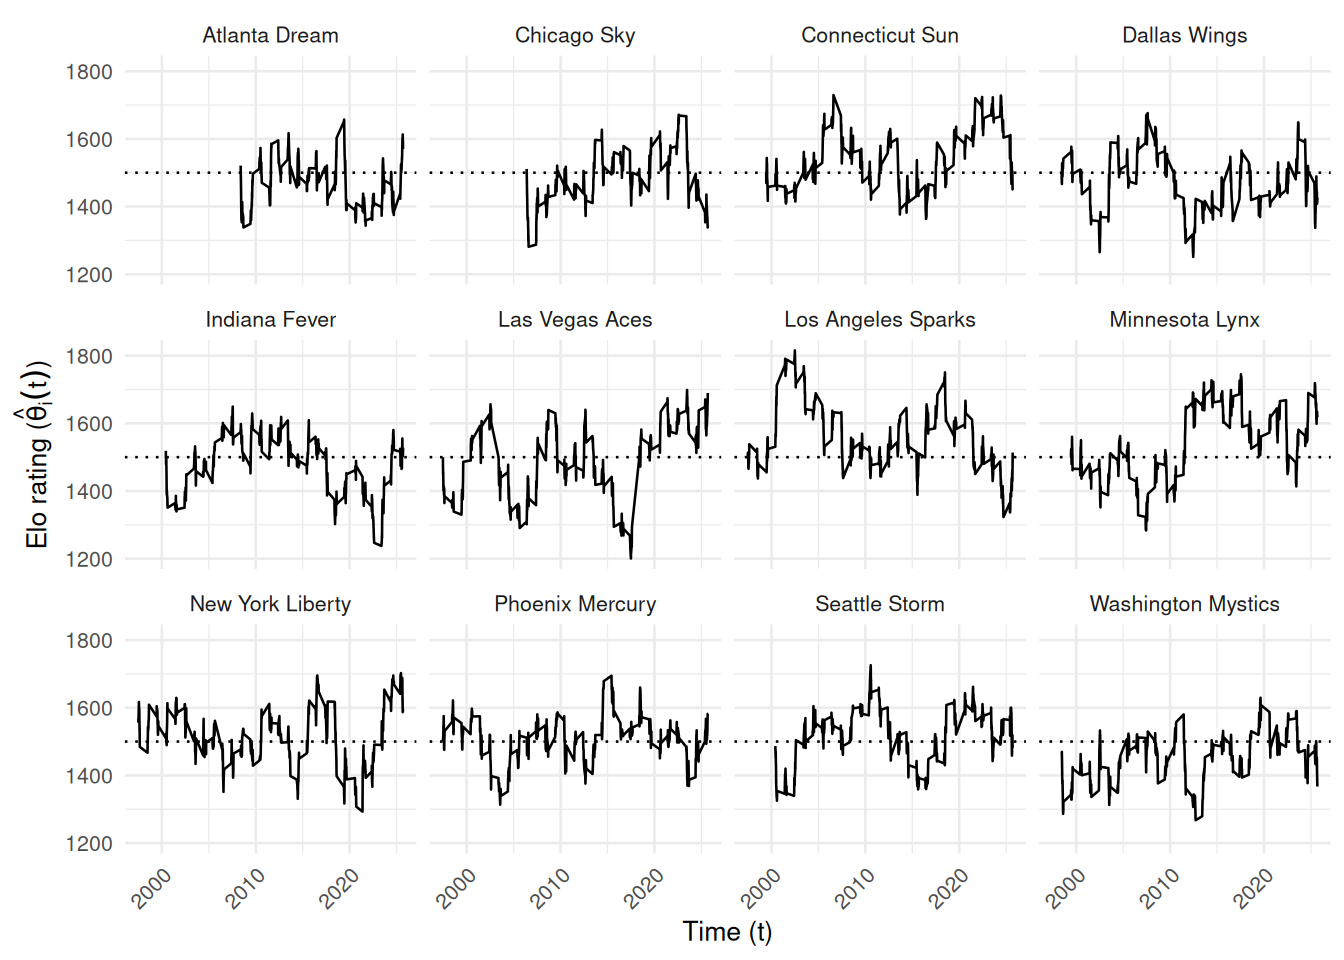

In [ ]:
wnba_gl |>
  filter(is_active, team_abbreviation != "GSV") |>
  ggplot(aes(x = game_date, y = elo_home_pregame)) +
  geom_hline(aes(yintercept = 1500), linetype = 3) +
  geom_line() +
  facet_wrap(vars(name_current)) +
  scale_y_continuous(latex2exp::TeX(r"(Elo rating ($\hat{\theta}_i(t)$))")) +
  scale_x_date("Time (t)") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Estimating home win probability

We also added a home court advantage equivalent to 60 points (of Elo rating) to our home win probability model, so that:
$$  \hat{p}_{ij}(t) = \Pr(i \text{ beats }j \text{ at time }t \text{ at home}) = \frac{1}{1 + 10^{\frac{\hat{\theta}_{j}(t) - \left( \hat{\theta}_{i}(t) + 60 \right)  }{400}}} \,.$$
We arrived at 60 points by iteratively calibrating the win probabilities to match the observed frequencies by minimizing the Brier score. The model fit very well for most of the games (see @tbl-calibrate).

In [ ]:
wnba_gl |>
  group_by(wpct_bin = cut(elo_home_win_prob, breaks = 10)) |>
  summarize(
    games = n(),
    bin_midpoint = median(elo_home_win_prob),
    obs_home_wpct = mean(win_flag, na.rm = TRUE)
  ) |>
  mutate(diff = obs_home_wpct - bin_midpoint) |>
  janitor::clean_names(case = "title") |>
  gt() |>
  tab_header(
    title = "WNBA Home Win Probability Model Calibration (1997-2025)",
    subtitle = "10 Equally-spaced Bins"
  ) |>
  fmt_number(
    decimals = 3
  ) |>
  fmt_number(columns = Games, decimals = 0) |>
  tab_options(
    table.font.size = px(11),
    table.width = pct(100)
  )

## Methods

### Response variables

Our goal is to model the attendance ($y$) at a given WNBA game, as a function of several different measures of fan engagement detailed in @sec-fan. We also include several control variables to account for time and city-related effects (see @sec-control).

Since we know the arena in which the game took place and the capacity of that arena, we also developed an alternative response variable: percentage of estimated arena capacity filled ($\gamma$).

In @fig-attendance-year, we observe the relationship between attendance and estimated home win probability. We add a simple quadratic regression line to reflect the quadratic relationship posited by @CoatesHumphreysZhou2014. In most years, the slope appears to be positive and the curvature concave.

> **Ben**
>
> How does this compare to Coates, et al?

Warning in scale_y_log10("Attendance"): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

(`stat_smooth()`).

(`geom_point()`).

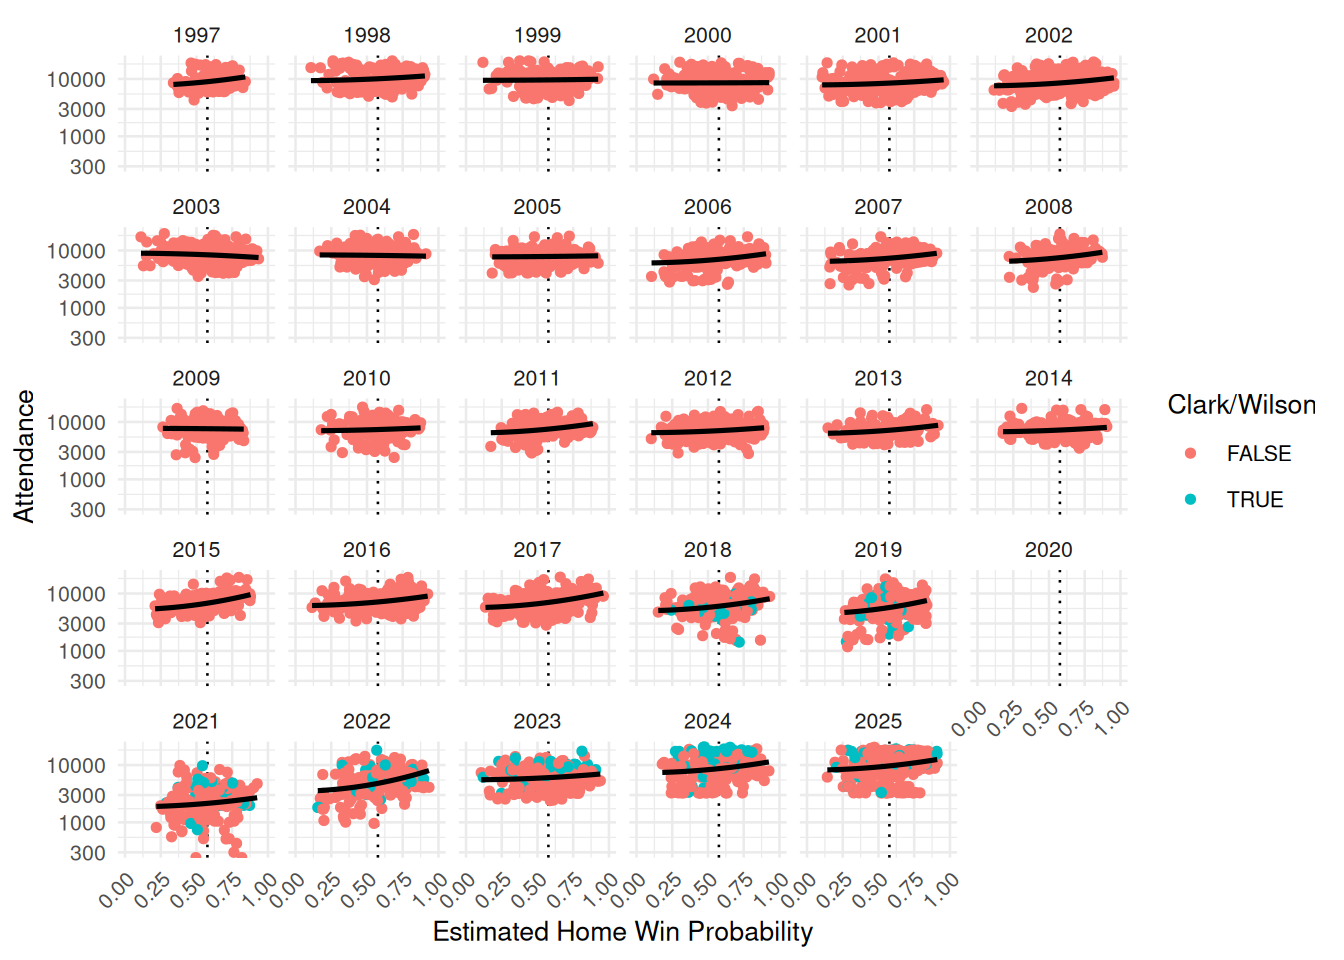

In [ ]:
plot_attend <- ggplot(wnba_gl, aes(x = elo_home_win_prob, y = attendance)) +
  geom_vline(aes(xintercept = mean(elo_home_win_prob)), linetype = 3) +
#  geom_hline(aes(yintercept = mean(attendance)), linetype = 3) +
  geom_point(aes(color = factor(is_cc | is_aw))) +
  geom_smooth(method = "lm", formula = y ~ I(x^2), se = 0, color = "black") +
  facet_wrap(vars(season_id)) +
  scale_x_continuous("Estimated Home Win Probability", limits = c(0, 1)) +
  scale_color_discrete(name = "Clark/Wilson") +
  theme_minimal(base_size = 10)+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
plot_attend +
  scale_y_log10("Attendance")

In @fig-capacity-year, we note similar trends in the relationship between the percentage of the estimated arena capacity filled and the estimated home win probability. We also note that since the percentage of arena capacity cannot exceed 1, there are edge effects created by sellouts. Those sellouts are much more frequent in the last two years of data, and many of the sellouts involve Caitlin Clark.

(`stat_smooth()`).

(`geom_point()`).

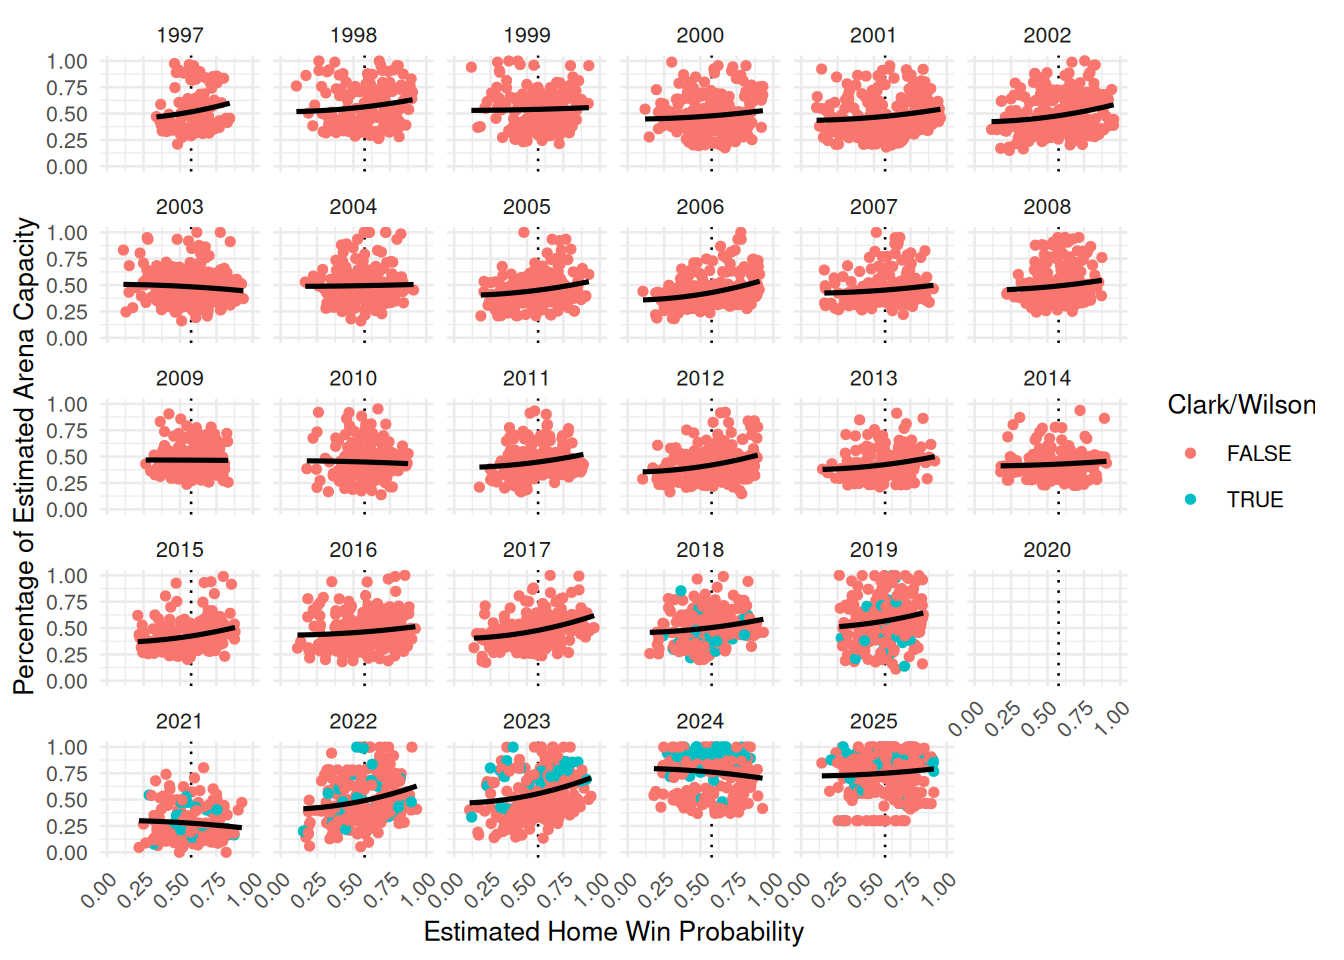

In [ ]:
plot_capacity <- plot_attend +
  aes(y = pct_capacity) +
  scale_y_continuous("Percentage of Estimated Arena Capacity")
plot_capacity

@tbl-sellout summarizes attendance figures across the 10 arenas with the most sellouts. We make several observations. The Golden State Valkyries (a 2025 expansion franchise) sold out all 22 of their games at the Chase Center. In terms of measuring fan demand, there is a profound difference between selling out a small arena (e.g., the Entertainment and Sports Arena in Washington, D.C. with a capacity of slightly more than 4000) and a large arena (e.g., Gainbridge Fieldhouse in Indianapolis, with a capacity of more than 18000). Teams like Washington and Connecticut may have been trying to maximize the percentage of arena capacity at the expense of drawing larger crowds. Or perhaps they didn’t have a larger arena in which to play. Just two of the 27 sellouts at Gainbridge Fieldhouse occurred before Clark’s arrival.

In [ ]:
wnba_gl |>
  group_by(arena) |>
  summarize(
    home_teams = paste(unique(team_abbreviation), collapse = ", "),
    num_games = n(),
    max_attendance = max(attendance),
    avg_attendance = mean(attendance, na.rm = TRUE),
    num_sellouts = sum(is_sellout, na.rm = TRUE)
  ) |>
  arrange(desc(num_sellouts)) |> 
  slice_head(n = 10) |>
  bind_rows(
    wnba_gl |>
      summarize(
        arena = paste("Total among", n_distinct(arena), "arenas"),
        home_teams = as.character(n_distinct(team_id)),
        num_games = n(),
        max_attendance = max(attendance, na.rm = TRUE),
        avg_attendance = mean(attendance, na.rm = TRUE),
        num_sellouts = sum(is_sellout, na.rm = TRUE)
      )
  ) |>
  mutate(
    pct_sellouts = num_sellouts / num_games,
    avg_capacity = avg_attendance / max_attendance
  ) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = c(0, 0, 0, 0, 1, 0, 2, 2))

  ---------------------------------------------------------------------------------------------
  Arena              Home        Num          Max          Avg        Num        Pct        Avg
                     Teams     Games   Attendance   Attendance   Sellouts   Sellouts   Capacity
  ------------------ ------- ------- ------------ ------------ ---------- ---------- ----------
  Entertainment and  WAS          84         4210       3578.3         47       0.56       0.85
  Sports Arena                                                                       

  Gainbridge         IND         404        18345       8573.0         27       0.07       0.47
  Fieldhouse                                                                         

  Chase Center       GSV          22        18064      18064.0         22       1.00       1.00

  Mohegan Sun Arena  CON         381         9518       6690.8         16       0.04       0.70

  Barclays Center    NYL          97        17758       9288.1         14       0.14       0.52

  Capital One Arena  WAS         357        20711      10673.8         14       0.04       0.52

  Crypto.com Arena   LAS         401        19282       9645.7         10       0.02       0.50

  Compaq Center      HOU         144        16285      10265.2          9       0.06       0.63

  ARCO Arena         SAC         212        17317       8324.1          7       0.03       0.48

  Madison Square     NYL         292        19563      11347.6          6       0.02       0.58
  Garden                                                                             

  Total among 60     19         6164        20711       8076.6        218       0.04       0.39
  arenas                                                                             
  ---------------------------------------------------------------------------------------------


### Modeling fan engagement

In @sec-elo, we described our use of Elo rating to estimate the strength of the home team ($\hat{\theta}_i(t)$), the strength of the visiting team ($\hat{\theta}_j(t)$) and the home win probability ($\hat{p}_{ij}(t)$) (which is itself a function of the estimated team strengths).

As noted in @sec-intro, there are multiple notions of what drives fan engagement relevant to the WNBA. Each of these notions can be captured by a simple bivariate function of the corresponding strengths of the teams $f_k(i, j, t) = f_k(\hat{\theta}_i(t), \hat{\theta}_j(t))$. The first and third have been rescaled so that they will have means close to 0.

- Quality of play: fans may wish to attend a game in person if they expect the quality of play to be high. We model this as the product of the Elo rating of the two teams ($f_1(i, j, t) = \hat{\theta}_i(t) \cdot \hat{\theta}_j(t)$)
- Uncertainty of outcome: fans may wish to attend a game for which the outcome is uncertain. We model this as negative square root of the absolute difference in the two teams’ Elo ratings: ($f_2(i, j, t) = -\sqrt{|\hat{\theta}_i(t) - \hat{\theta}_j(t)|}$). The negative sign ensures that closely-matched opponents will have the highest values, and the square root helps to make the spread more symmetric.
- Loss aversion: fans may wish to attend a game to see their team (the home team) win. We model this using the estimated home win probability function above ($f_3(i, j, t) = (\hat{p}_{ij}(t))^2$). Note that this term is nonlinear as in @CoatesHumphreysZhou2014.

The distribution of attendance with respect to $f_1$ and $f_2$ are shown in @fig-attend-f1 and @fig-attend-f2, respectively, with the corresponding plots for percentage of estimated arena capacity shown in @fig-capacity-f1 and @fig-capacity-f2.

#### Normalization

@fig-rescaled shows the distribution of our fan engagement variables after normalizing ($Z_k = \frac{f_k - \mu(f_k)}{\sigma(f_k)}$). We note that @tbl-cor shows that our three fan engagement variables are largely uncorrelated.

In [ ]:
wnba_gl |>
  select(matches("^z[0-9]_")) |>
  cor() |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  -------------------------------------------------------------------------
                          Z1 Quality of        Z2 Uncertain         Z3 Loss
                                   Play             Outcome        Aversion
  ------------------- ----------------- ------------------- ---------------
  Z1 Quality of Play              1.000              -0.022          -0.003

  Z2 Uncertain                   -0.022               1.000          -0.103
  Outcome                                                   

  Z3 Loss Aversion               -0.003              -0.103           1.000
  -------------------------------------------------------------------------


@fig-all-z illustrates how our normalized measures of fan engagement vary with respect to the estimated (pregame) strength of the home and away teams. The lack of correlation across these measures reported in @tbl-cor is apparent graphically. The 4th panel in @fig-all-z shows the simple sum of the three measures of fan engagement. Although this metric is not used directly in our analysis, it might be considered a composite of three competing, uncorrelated notions of fan engagement.

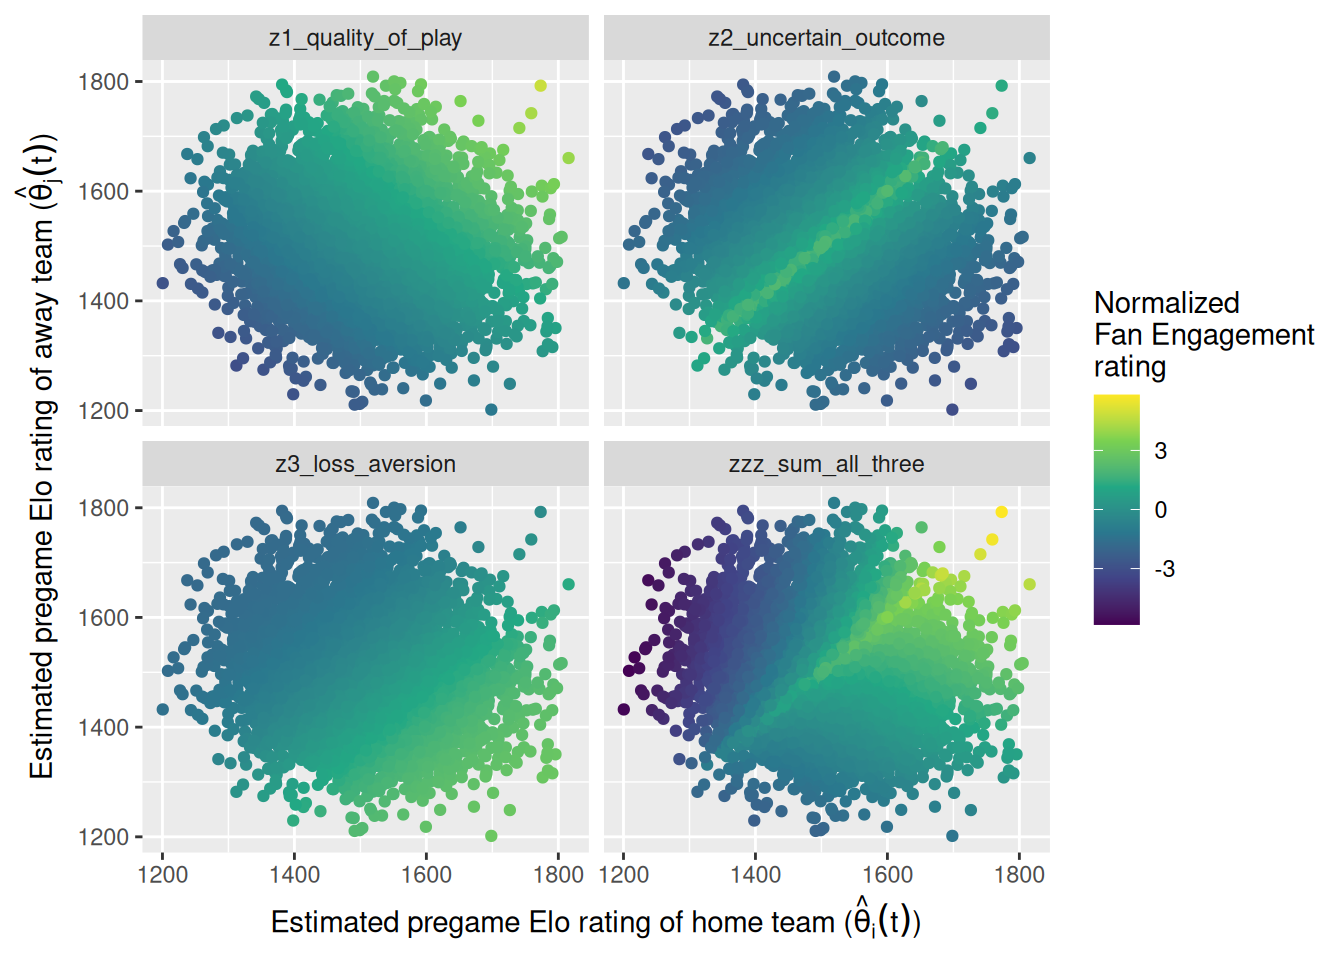

In [ ]:
wnba_gl |>
  select(contains("pregame"), matches("^z")) |>
  pivot_longer(cols = !contains("pregame"), names_to = "variable", values_to = "value") |>
  ggplot(aes(x = elo_home_pregame, y = elo_away_pregame, color = value)) +
  geom_point() +
  facet_wrap(vars(variable)) +
  scale_color_viridis_c(name = "Normalized\nFan Engagement\nrating") +
  scale_x_continuous(latex2exp::TeX(r"(Estimated pregame Elo rating of home team ($\hat{\theta}_i(t)$))")) +
  scale_y_continuous(latex2exp::TeX(r"(Estimated pregame Elo rating of away team ($\hat{\theta}_j(t)$))"))

### Control variables

As time-related control variables, we include the the season ($\tau_1$), the month of the year ($\tau_2$), and day of the week ($\tau_3$) as fixed effects. To control for city-related effects, we also include the team name ($\phi_1$), as well as the metropolitan area median income ($\phi_2$, in thousands of USD) and population ($\phi_3$, in millions) of the home city[1]. Finally, we include an indicator based on whether Caitlin Clark or A’ja Wilson played more than 0 minutes in the game ($\chi_1, \chi_2$, respectively).

### Interaction

Testing our primary hypotheses requires analyzing how the relationships between attendance and fan engagement have changed over time. To capture these changes, we include interaction terms between our measures of fan engagement ($f_k$) and season ($\tau_1$).

### Model formulation for attendance

[1] The data for the population and the median income of cities comes from the American Community Survey, access to which was provided in R by the **tidycensus** \[@R-tidycensus\] package. Because the population and median income statistics were available at irregular time periods (due to the COVID-19 pandemic and other factors), impute missing values using a cubic spline for interpolated values and the last observation carried forward (or backward) for extraploted values.

In [ ]:
f_time <- "factor(season_id) + as.character(wday(game_date, label = TRUE, abbr = FALSE)) + as.character(month(game_date, label = TRUE, abbr = FALSE))"
f_place <- "factor(name_current) + median_income + metro_pop + is_cc + is_aw"
f_exp <- c("(I(z1_quality_of_play) + I(z2_uncertain_outcome) + I(z3_loss_aversion))")

wnba_df <- wnba_gl |>
  filter(!season_id %in% c(2020, 2021), is_active) |>
  filter_out(is.na(attendance))

form_basic <- paste("log(attendance + 1) ~ ", f_exp, "+", f_place, "+", f_time) |>
  as.formula()

form_interaction <- update(form_basic, paste(". ~ . + ", f_exp, "* factor(season_id)"))

In [ ]:
# OLS model
mod_ols_basic <- lm(formula = form_basic, data = wnba_df)
mod_ols <- lm(formula = form_interaction, data = wnba_df)

Because the raw attendance figures are not normally distributed, we model the logarithm of attendance. Similarly, because the percentage of arena capacity are bound above by 1 and below by 0, we employ a Tobit regression model.

Like @CoatesHumphreysZhou2014, we model the natural logarithm of attendance.

Our general regression model for attendance is: where $\beta_j \in \mathbb{R}$ for $j = \{0, 1, 2, 3, 11, 12\}$, while the other $\beta_j$ coefficients are vectors of length equal to the number of factor levels in their corresponding categorical explanatory variable minus 1. Most notably $\beta_5$ and $\beta_8$ have 26 values (corresponding to each season after 1997) and $\beta_5$ has 12 values (corresponding to each team). Only current WNBA franchises are included in the regression model. We also excluded all data from the 2020 and 2021 seasons, since there were no fans allowed in all or parts of both seasons.

In [ ]:
# Tobit model
library(VGAM)

Loading required package: stats4

Loading required package: splines

Warning in eval(slot(family, "initialize")): replacing response values >
'Upper' by 'Upper'

Warning in eval(slot(family, "initialize")): replacing response values >
'Upper' by 'Upper'

> **Ben**
>
> Need to add details about Tobit modeling.

We fit the Tobit model in R using the `vglm()` and `tobit()` functions from the **VGAM** \[@R-VGAM\] package.

### Model formulation for percentage of arena capacity

We fit the same model with $\gamma$ as the response, but because our response variable $\gamma$ is constrained between 0 and 1 and has significant mass at 1 exactly, we use the Papke-Wooldridge fractional response model \[@papke1996econometric\]. This is equivalent to fitting a generalized linear model with a logit link function and applying HC1 sandwich estimators \[@mackinnon1985some\] for the covariance matrix, which we accomplish using the **sandwich** \[@R-sandwich\] package in R.
$$  \mathbb{E}{(\gamma | \symbf{X})} = G(\symbf{X} \symbf{\eta}) \,,$$
where $G(z) = \frac{e^z}{1 + e^z}$ is the (vectorized) logistic function, $\symbf{X}$ is as above, and $\symbf{\eta}$ has the same structure as $\symbf{\beta}$ defined above.

## Results

In keeping with recent guidance from @wasserstein2016asa and @wasserstein2019moving, and with a sample size of over 5000 observations and dozens of coefficients, we are less interested in the p-values shown in @tbl-coefs, and focus our attention on the magnitude and practical impact of the fitted coefficients. (All variables except for population achieve “statistical significance” at the 5%-level, as shown in @tbl-anova-tobit).

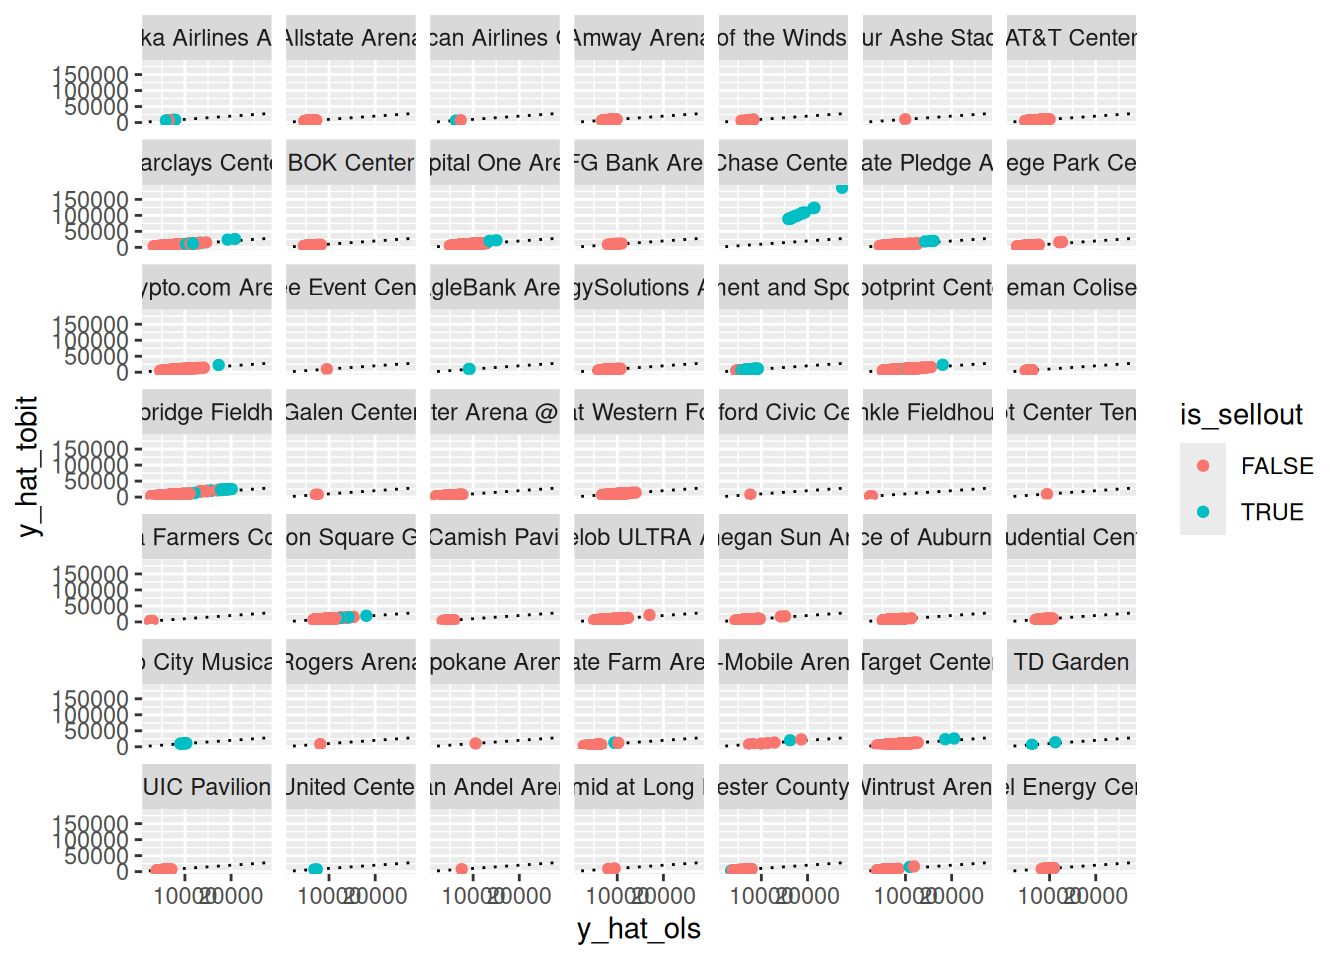

# A tibble: 1 × 1
  cor[,1]
    <dbl>
1   0.618

In [ ]:
wnba_df <- wnba_df |>
  mutate(
    y_hat_ols = exp(fitted(mod_ols)),
    y_hat_tobit = exp(fitted(mod_tobit))
  )

ggplot(data = wnba_df, aes(x = y_hat_ols, y = y_hat_tobit, color = is_sellout)) +
  geom_abline(slope = 1, linetype = 3) + 
  geom_point() +
  facet_wrap(vars(arena))

In [ ]:
library(broom)
tidy.vglm <- broom.helpers::tidy_vgam

### Modeling attendance

#### Baseline effects

@tbl-coefs reports estimates from the Tobit model. Because each measure of fan engagement interacts with season, the reported coefficients for quality of play, outcome uncertainty, and loss aversion represent their estimated effects for the reference levels: a home game for the Atlanta Dream taking place on a Sunday in May (in which neither Clark nor Wilson is playing). The interaction terms, discussed in @sec-annual, capture how these relationships evolve over time.

In [ ]:
sanitize_terms <- function(x) {
  x |>
    str_replace_all("factor\\(name_current\\)", "Team: ") |>
    str_replace_all("as.character\\(wday\\(game_date\\, label = TRUE\\, abbr = FALSE\\)\\)", "Day: ") |>
    str_replace_all("as.character\\(month\\(game_date\\, label = TRUE\\, abbr = FALSE\\)\\)", "Month: ") |>
    str_replace_all("is_cc", "Player: Caitlin Clark") |>
    str_replace_all("is_aw", "Player: A'ja Wilson")
}

In [ ]:
mod_attend_coefs <- mod_attend |>
  tidy(conf.int = TRUE) |>
#  map(broom::tidy, conf.int = TRUE) |>
  bind_rows(.id = "model") 

min_cc <- mod_attend_coefs |>
  filter(term == "is_cc") |>
  select(estimate) |>
  min()

beta_quality <- mod_attend_coefs |>
  filter(term == "I(z1_quality_of_play)") |>
  pull(estimate)

mod_attend_coefs |>
  filter_out(str_detect(term, "factor|name_current|character")) |>
  select(term = original_term, estimate, std.error, statistic, p.value, conf.low, conf.high) |>
  mutate(term = sanitize_terms(term)) |>
  arrange(term) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  -----------------------------------------------------------------------------------
  Term                        Estimate      Std   Statistic P Value Conf Low     Conf
                                          Error                                  High
  ------------------------- ---------- -------- ----------- ------- -------- --------
  (Intercept):1                  9.185    0.085     107.839   0.000    9.018    9.352

  (Intercept):2                 -1.181    0.010    -117.733   0.000   -1.201   -1.162

  I(z1_quality_of_play)          0.212    0.079       2.677   0.007    0.057    0.368

  I(z2_uncertain_outcome)        0.019    0.045       0.430   0.667   -0.069    0.108

  I(z3_loss_aversion)            0.025    0.056       0.440   0.660   -0.085    0.135

  Player: A'ja Wilson            0.048    0.026       1.828   0.068   -0.003    0.099

  Player: Caitlin Clark          0.846    0.054      15.543   0.000    0.739    0.953

  median_income                 -0.006    0.001      -4.169   0.000   -0.008   -0.003

  metro_pop                     -0.016    0.006      -2.586   0.010   -0.029   -0.004
  -----------------------------------------------------------------------------------


In the reference season, the evidence for loss aversion ($Z_3$) and uncertainty of outcome ($Z_2$) is weak, with those coefficients being of little significance, either practically or statistically. The coefficient for quality of play (which *is* statistically significant) suggest that in 1997, a 1 standard deviation increase in the quality of play (as measured by the product of the Elo ratings) is associated with a modest 2.15% increase in the expected attendance, after controlling for our other factors. The strong support for quality of play (relative to uncertainty of outcome and loss aversion) is a key finding.

Games featuring Caitlin Clark were associated with significantly higher attendance, while A’ja Wilson’s presence was associated with a smaller but still nontrivial increase in attendance. The expected attendance more than doubles (i.e., is multiplied by $\exp(\text{0.846})$ = 2.33) when Clark plays in the game, and this is *after* controlling for the Indiana Fever team effect, the level of fan engagement, and the season effects! The corresponding change in attendance for A’ja Wilson—by most accounts a better player than Clark—is multiplying by just 1.05.

> **Ben**
>
> Need to provide an interpretation for the Tobit coefficient.

Among the control variables, median income and metro area population had small negative effects after controlling for other variables.

@fig-attend-coefs presents the results of @tbl-coefs and some additional coefficients graphically. Confidence intervals for the coefficient associated with the Golden State Valkyries is omitted because it was so large that it renders all of the other effects indistinguishable. The New York Liberty have the largest team effect, and all teams are positive relative to the Dream. Saturday games have the highest attendance, as do games later in the season.

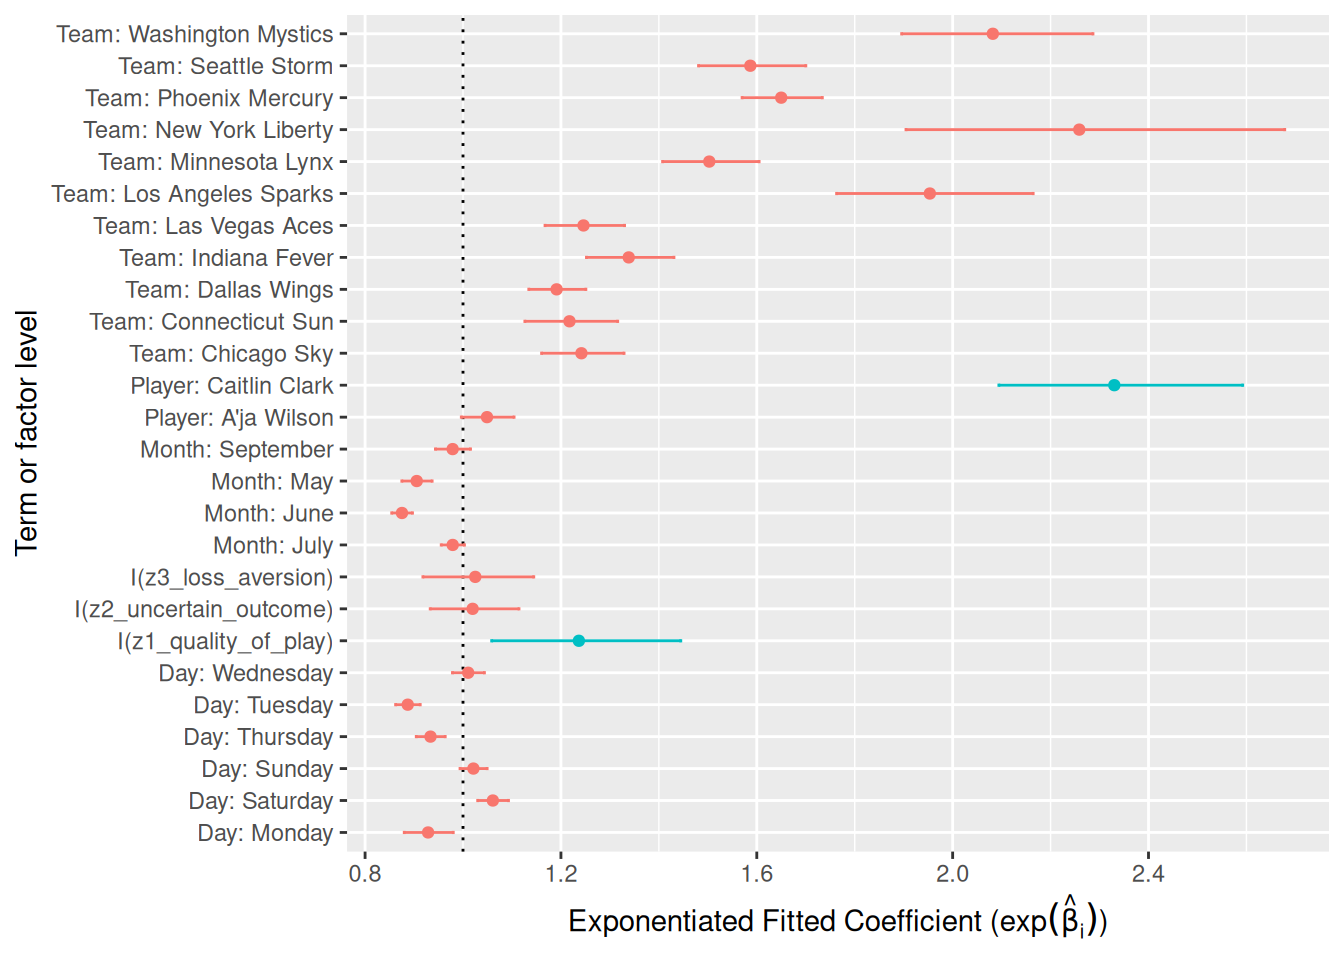

In [ ]:
plot_attend_coefs <- mod_attend_coefs |>
  filter_out(str_detect(term, "(arena)|:|Intercept|median|metro|season|Golden")) |>
  mutate(
    hilite = str_detect(term, "is_cc|2025|quality"),
    term = sanitize_terms(term)
  ) |>
  ggplot(aes(x = exp(estimate), y = term, color = hilite)) +
  geom_vline(xintercept = 1, linetype = 3) +
  geom_point() +
  geom_errorbar(aes(xmin = exp(conf.low), xmax = exp(conf.high)), width = 0.1) +
  scale_x_continuous(latex2exp::TeX(r"(Exponentiated Fitted Coefficient ($\exp{(\hat{\beta}_i)}$))")) +
  scale_y_discrete("Term or factor level") +
  scale_color_discrete(guide = "none")
plot_attend_coefs

In [ ]:
glance.vglm <- function(x, ...) {
  tibble::tibble(
    nobs        = VGAM::nobs(x),
    df.residual = VGAM::df.residual(x),
    logLik      = as.numeric(stats::logLik(x)),
    AIC         = AIC(x),
    BIC         = BIC(x),
#    deviance    = if (length(x@criterion$deviance) > 0) x@criterion$deviance else NA_real_
  )
}

@tbl-glance characterizes the model’s fit.

#### Annual effects

@tbl-lrt shows a likelihood ratio test between our model and a reduced model that does not include the interaction terms. The interactions introduce 78 additional terms corresponding to season specific slopes to our model. The likelihood ratio test rejects the null hypothesis that all season-specific changes in slope are equal to zero, indicating that the effects of our fan engagement measures differ significantly across seasons.

The ANOVA tables shown in @tbl-anova-tobit further support the inclusion of all three sets of interaction terms.

In [ ]:
anova(mod_tobit_basic, mod_tobit, type = "I") |>
  knitr::kable(digits = 3)

    Resid. Df      LogLik   Df   2 \* LogLik Diff.   Pr(\>Chi)
  ----------- ----------- ---- ------------------- -----------
        10069   -1481.836   NA                  NA          NA
         9991   -1283.677   78             396.318           0


@fig-season-coefs isolates the changes intercept associated with each WNBA season. These reveal that even after controlling for our others variables—including the Caitlin Clark effect—expected attendance has exceeded its 1997 baseline in the most recent seasons. Thus, after controlling for the influence of Clark and Wilson, league expected attendance has fully recovered from the COVID-19 pandemic and the malaise of the early 2000s and 2010s.

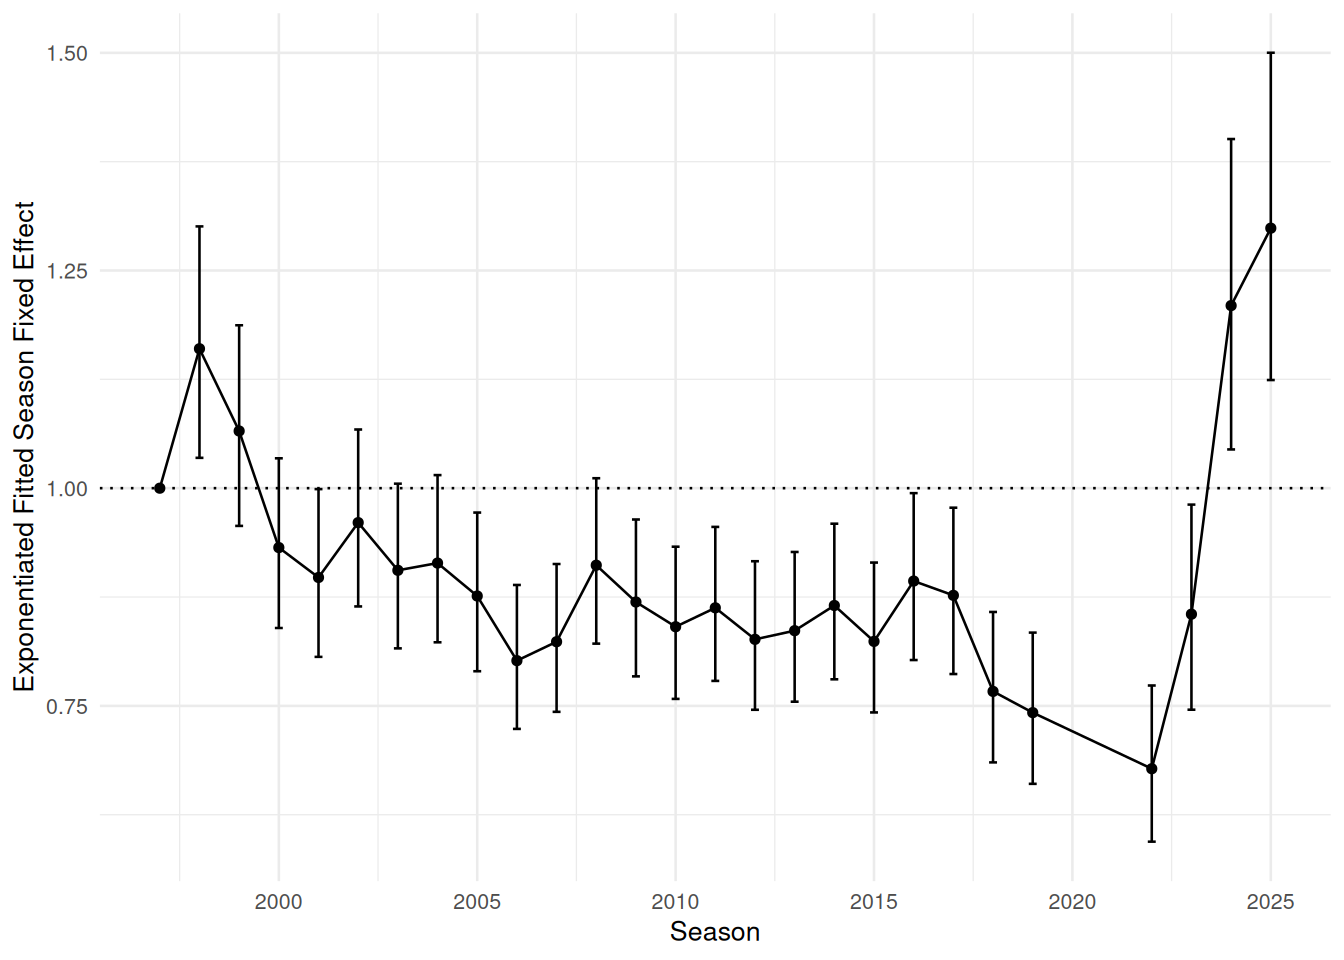

In [ ]:
plot_attend_seasons <- mod_attend_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  bind_rows(tibble(season_id = 1997, estimate = 0)) |>
  ggplot(aes(x = season_id, y = exp(estimate))) +
  geom_point() +
  geom_hline(yintercept = 1, linetype = 3) +
  geom_line() +
  geom_errorbar(aes(ymin = exp(conf.low), ymax = exp(conf.high), width = 0.2)) +
  scale_x_continuous("Season") +
  scale_y_continuous("Exponentiated Fitted Season Fixed Effect") +
  theme_minimal(base_size = 10)
plot_attend_seasons

@fig-season-slopes shows the exponentiated season-by-season combined slopes for our three measures of fan engagement. The initial values (corresponding to 1997), match those in @tbl-coefs, and the subsequent interaction terms modify the relationships between attendance and fan engagement. In @fig-season-slopes, we can see that there is little to no association with attendance from the uncertainty of the outcome. The slope associated with loss aversion always positive and generally increasing, suggesting that the attendance response to home win probability has strengthened over the league’s history. This suggests that fan behavior in the WNBA may becoming more similar to the behavior observed in MLB by @CoatesHumphreysZhou2014.

> **Ben**
>
> Say something about how this tracks with Agha and Berri.

Similarly, the slope associated with quality of play is always positive and generally increasing, following a steep fall after the league’s first season.

> **Ben**
>
> I’m not sure why the quality of play initial coefficient is so high and then drops off.

In the case of quality of play and loss aversion, the exponentiated fitted coefficient value of approximately 0.1 in recent years means that a one standard deviation increase in these measures is associated with an increase in attendance that is about 10% higher than it would have been in the league’s early years. This is another key finding.

In [ ]:
combine_slopes <- function(data) {
  slopes <- data |>
    filter(str_detect(term, "z")) |>
    mutate(
      type = ifelse(str_detect(term, "\\)$"), "main", "interaction"),
      season_id = parse_number(str_sub(term, -4)),
      variable = str_extract(term, "z[0-9][a-z,_]+")
    )
  
  main_slopes <- slopes |>
    filter(type == "main") |>
    mutate(season_id = 1997) |>
    select(season_id, variable, estimate, conf.low, conf.high)
  
  changes_in_slopes <- slopes |>
    filter(type == "interaction") |>
    select(season_id, variable, estimate, conf.low, conf.high) |>
    bind_rows(main_slopes)
  
  changes_in_slopes |>
    left_join(
      main_slopes |> select(variable, main_slope = estimate), 
      by = join_by(variable)
    ) |>
    mutate(combined_slope = main_slope + estimate)
}

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

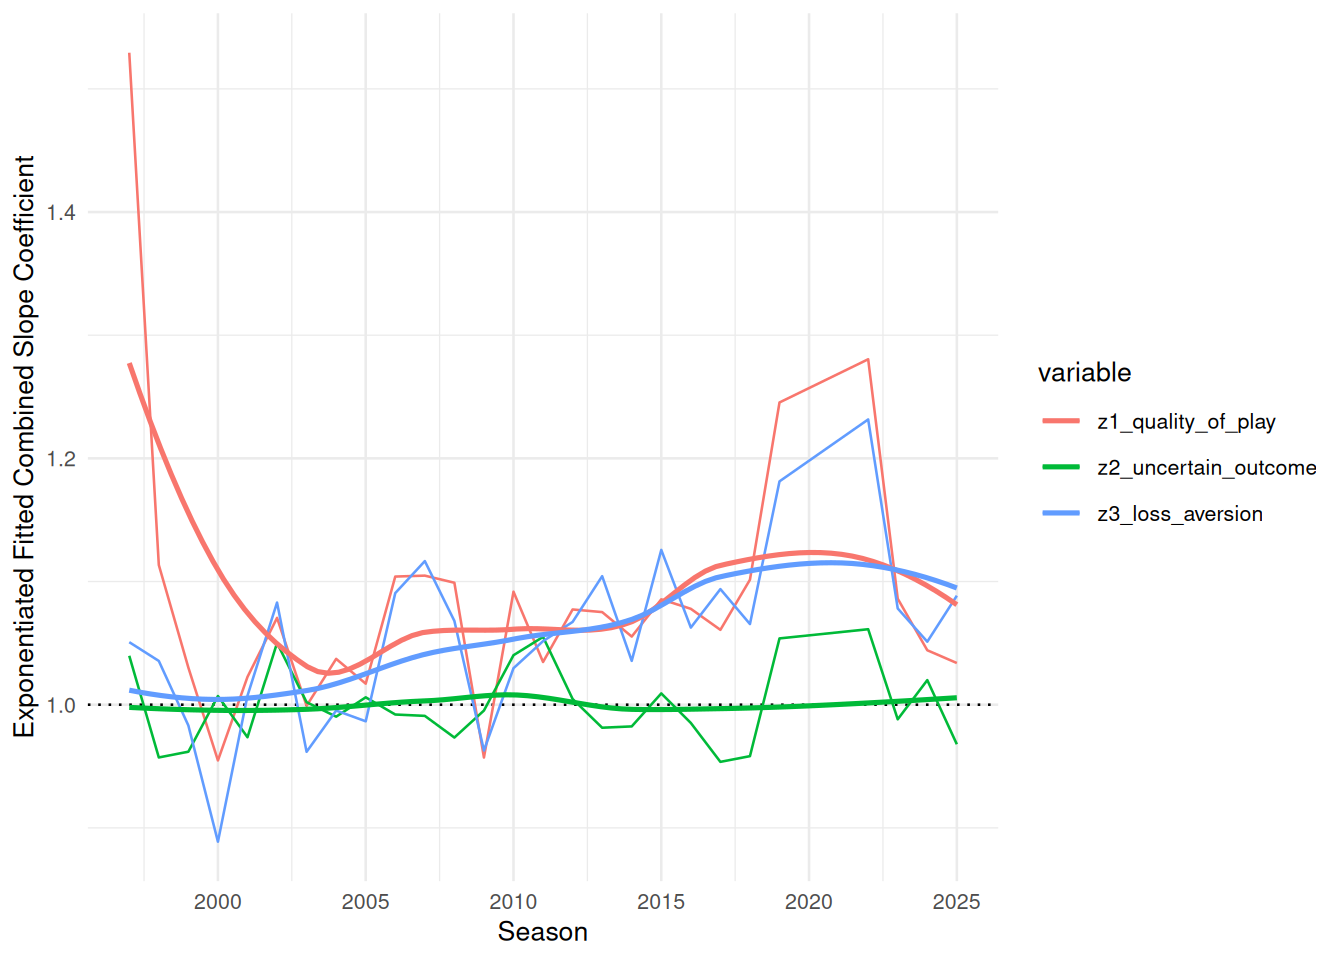

In [ ]:
plot_attend_slopes <- mod_attend_coefs |>
  combine_slopes() |>
  ggplot(aes(x = season_id, y = exp(combined_slope), color = variable)) +
  geom_hline(yintercept = 1, linetype = 3) +
  geom_line() +
#  geom_errorbar(aes(ymin = conf.low, ymax = conf.high, width = 0.2)) +
  geom_smooth(se = 0) +
  scale_x_continuous("Season") +
  scale_y_continuous("Exponentiated Fitted Combined Slope Coefficient") +
  theme_minimal(base_size = 10)
plot_attend_slopes

### Modeling percentage of arena capacity

Because our response variable $\gamma$ is constrained between 0 and 1, but has significant mass at 1 exactly, we fit a Papke-Wooldridge fractional response model \[@papke1996econometric\] with HC1 sandwich estimators for the covariance matrix.

In [ ]:
# Arena capacity
mod_tobit_pct <- vglm(
  formula = update(mod_ols, pct_capacity_safe ~ .),
  family = tobit(Upper = 1, Lower = 0, imethod = 2), 
  data = wnba_df,
  na.action = "na.exclude"
)

In [ ]:
library(lmtest)

Loading required package: zoo


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Attaching package: 'lmtest'

The following object is masked from 'package:VGAM':

    lrtest

#### Main effects

@tbl-coefs2 reports the coefficients from the percentage of arena capacity models.

In [ ]:
mod_pct_coefs <- mod_pct |>
  lmtest::coeftest(vcov_pct) |>
  broom::tidy(conf.int = TRUE)

mod_pct_coefs |>
  filter_out(str_detect(term, "factor|name|character")) |>  
  mutate(term = sanitize_terms(term)) |>
  arrange(term) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  -----------------------------------------------------------------------------------
  Term                        Estimate      Std   Statistic P Value Conf Low     Conf
                                          Error                                  High
  ------------------------- ---------- -------- ----------- ------- -------- --------
  (Intercept)                   -0.495    0.184      -2.695   0.007   -0.855   -0.135

  I(z1_quality_of_play)          0.506    0.181       2.793   0.005    0.151    0.862

  I(z2_uncertain_outcome)        0.136    0.097       1.396   0.163   -0.055    0.326

  I(z3_loss_aversion)            0.099    0.110       0.902   0.367   -0.116    0.315

  Player: A'ja Wilson            0.275    0.064       4.329   0.000    0.151    0.400

  Player: Caitlin Clark          1.917    0.114      16.809   0.000    1.694    2.141

  median_income                  0.006    0.003       1.844   0.065    0.000    0.012

  metro_pop                      0.111    0.012       8.954   0.000    0.086    0.135
  -----------------------------------------------------------------------------------


@fig-pct-coefs shows that…

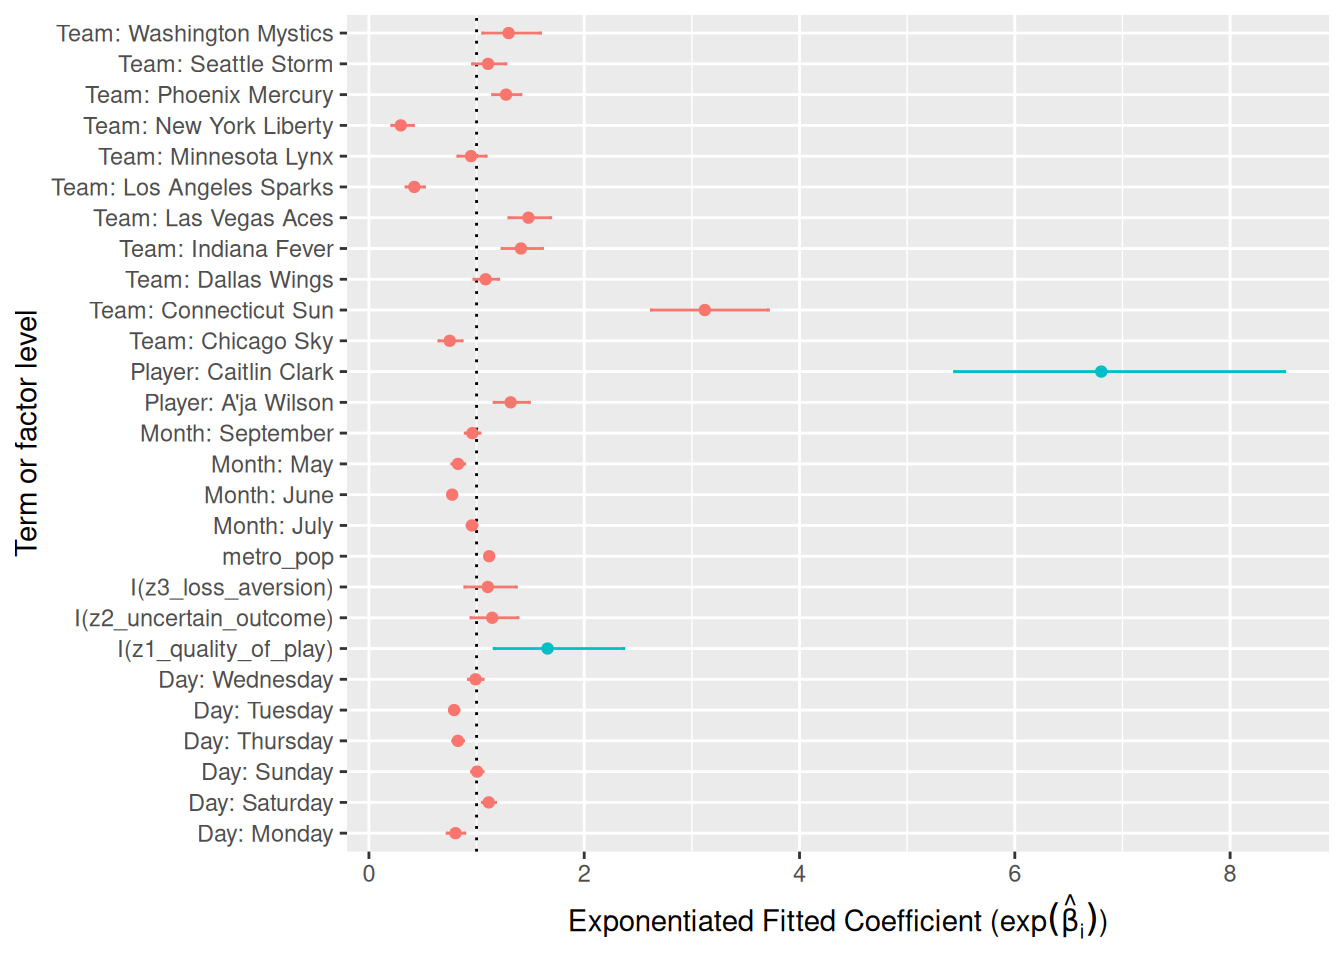

In [ ]:
plot_attend_coefs +
  mod_pct_coefs |>
  filter_out(str_detect(term, "(arena)|:|Intercept|median|Golden|season")) |>
  mutate(
    hilite = str_detect(term, "is_cc|2025|quality"),
    term = sanitize_terms(term)
  )

@tbl-glance2 and @tbl-anova2 show model fit metrics and analysis of variance for the percentage of estimated arena capacity models, respectively.

#### Annual effects

@fig-season-coefs2 displays the estimated effects of our fan engagement measures on attendance relative to the 1997 reference season. Similar to the overall attendance trends, these effects generally remained below their 1997 levels for much of the league’s history and only returned to comparable levels recently. In the most recent years of measurement, however, we see the league exceeding previously record-holding levels.

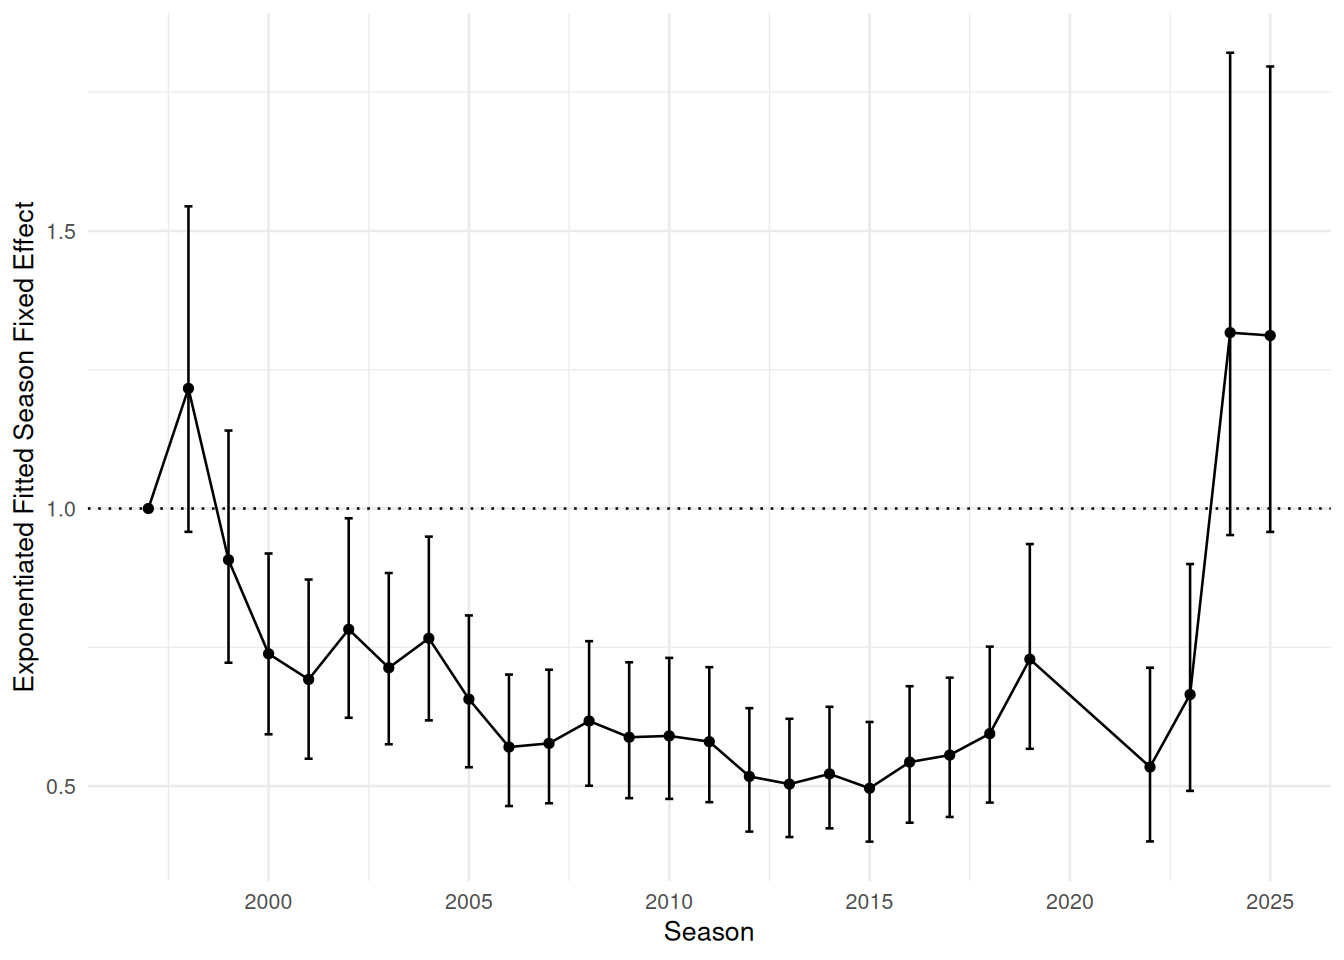

In [ ]:
plot_attend_seasons +
  mod_pct_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  bind_rows(tibble(season_id = 1997, estimate = 0))

@fig-season-slopes2 shows that…??

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

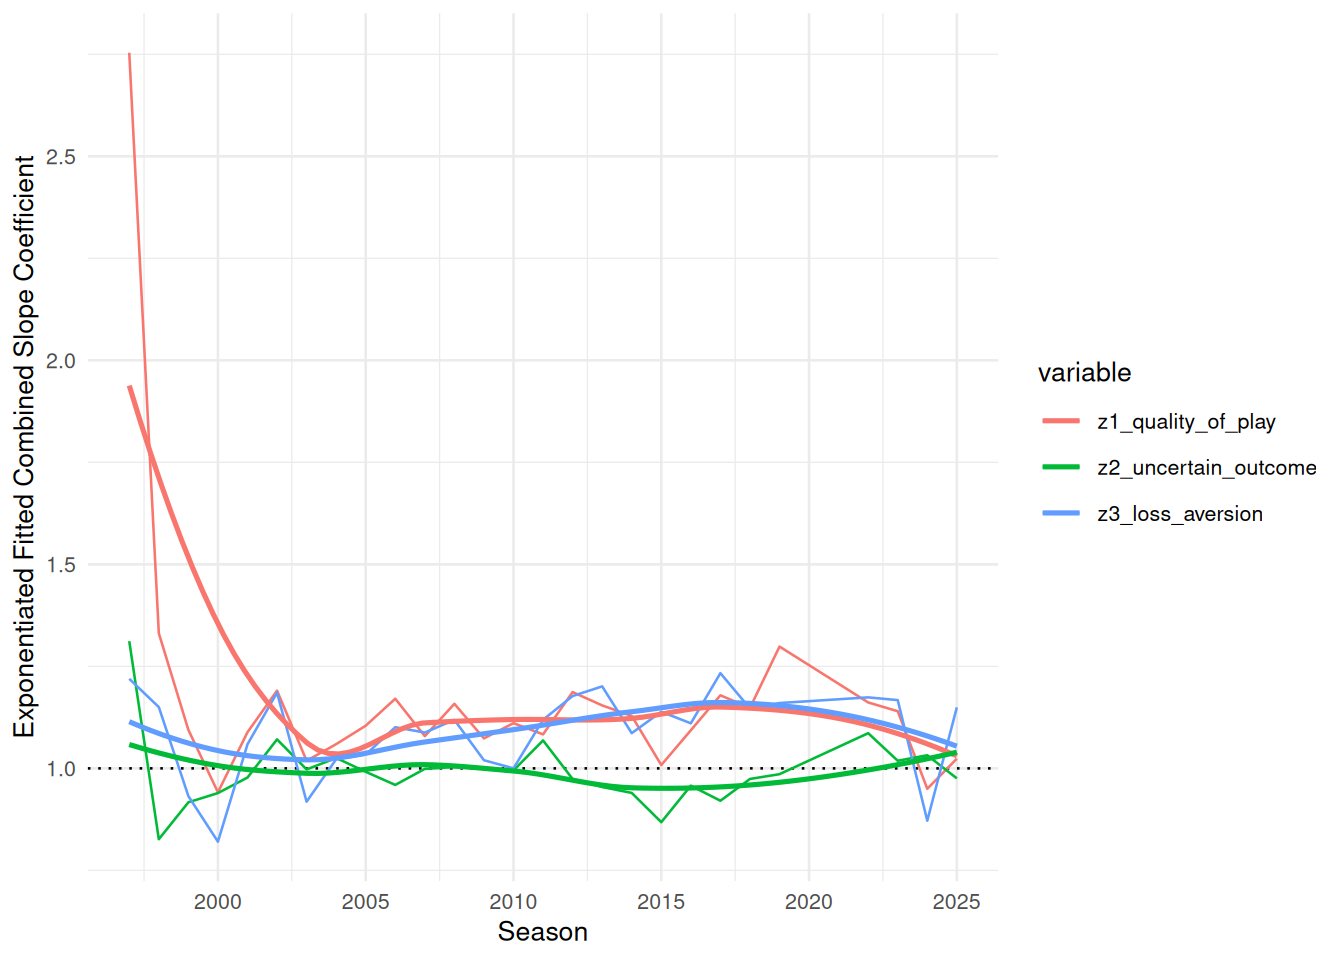

In [ ]:
plot_attend_slopes +
  mod_pct_coefs |>
  combine_slopes()

## Conclusion

### Limitations

Because the percentage of arena capacity data is right-censored, we considered a Tobit regression model \[@mcdonald1980uses\], but our residuals violated the normality and homoskedasticity conditions. We also considered fitting a Beta regression model with a logit link function, and converting the fixed effects for seasons to random effects, but those models didn’t converge.

We also considered fitting a period-based model but ultimately decided against this approach. Defining periods by hand would require subjective decisions about the timing of structural breaks and would risk introducing researcher bias into the analysis.

### Future work

### Discussion

## References

## Appendix

### Distribution of fan engagement

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

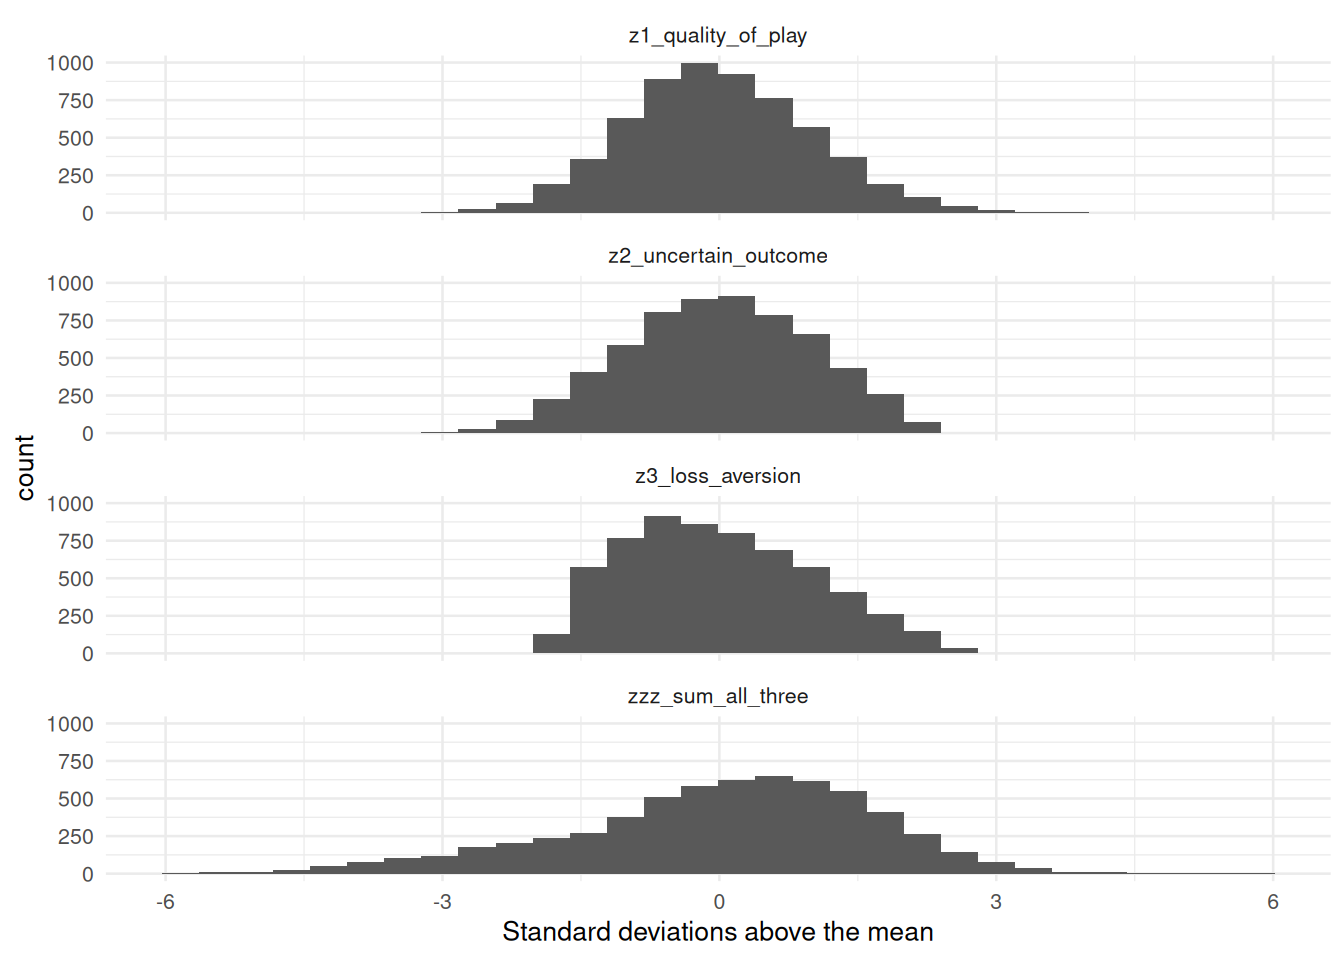

In [ ]:
wnba_gl |>
  select(matches("^z")) |>
  pivot_longer(cols = everything(), values_to = "value", names_to = "fan_engagement") |>
  ggplot(aes(x = value)) +
  geom_histogram() +
  facet_wrap(vars(fan_engagement), ncol = 1) + 
  theme_minimal(base_size = 10) +
  scale_x_continuous("Standard deviations above the mean")

### Relationship between attendance and fan engagement

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

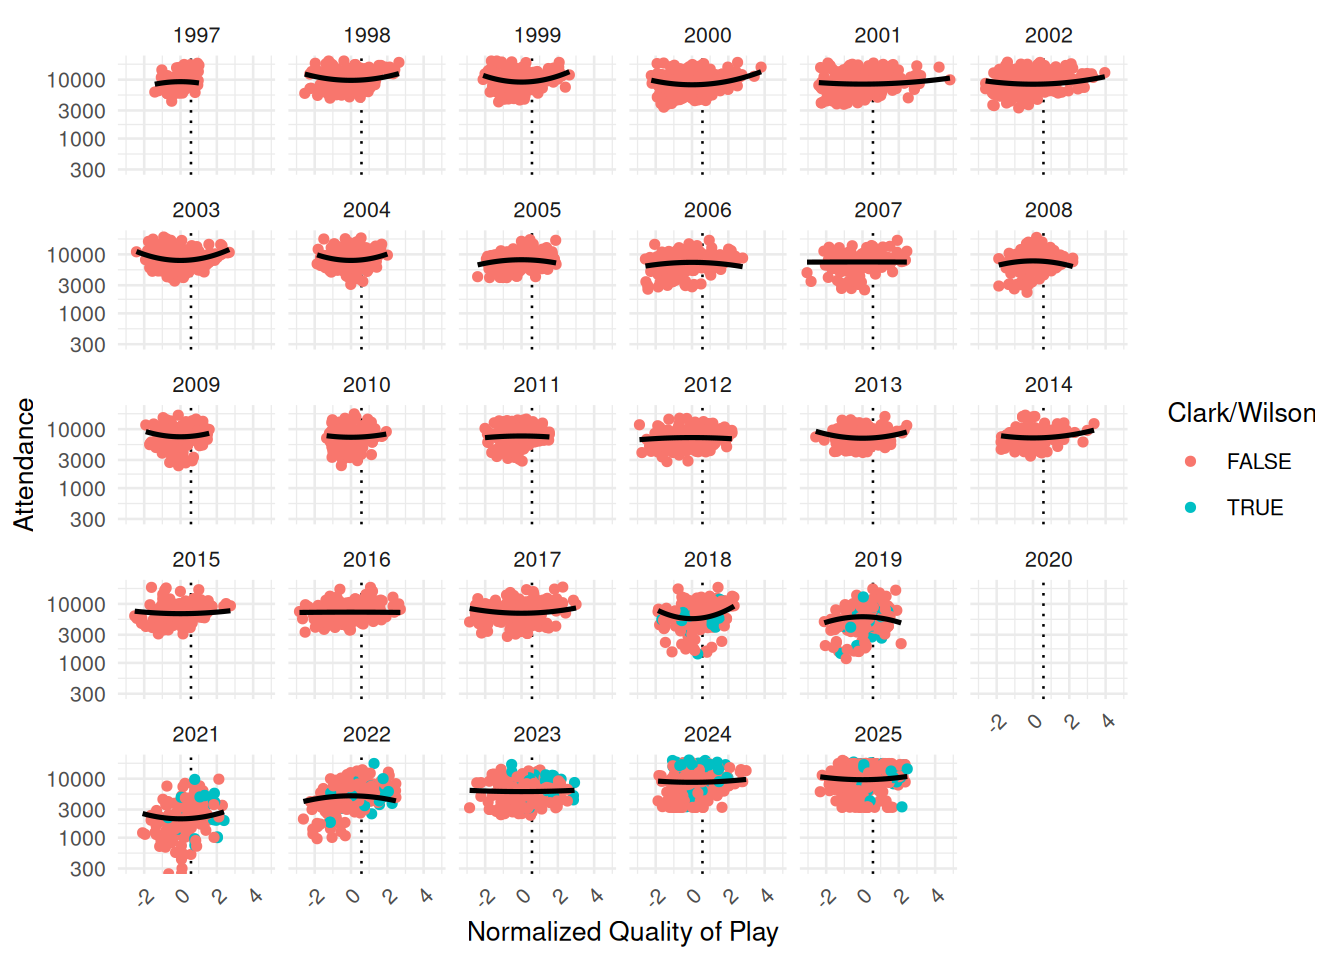

In [ ]:
plot_attend +
  aes(x = z1_quality_of_play) +
  scale_x_continuous("Normalized Quality of Play") +
  scale_y_log10("Attendance")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

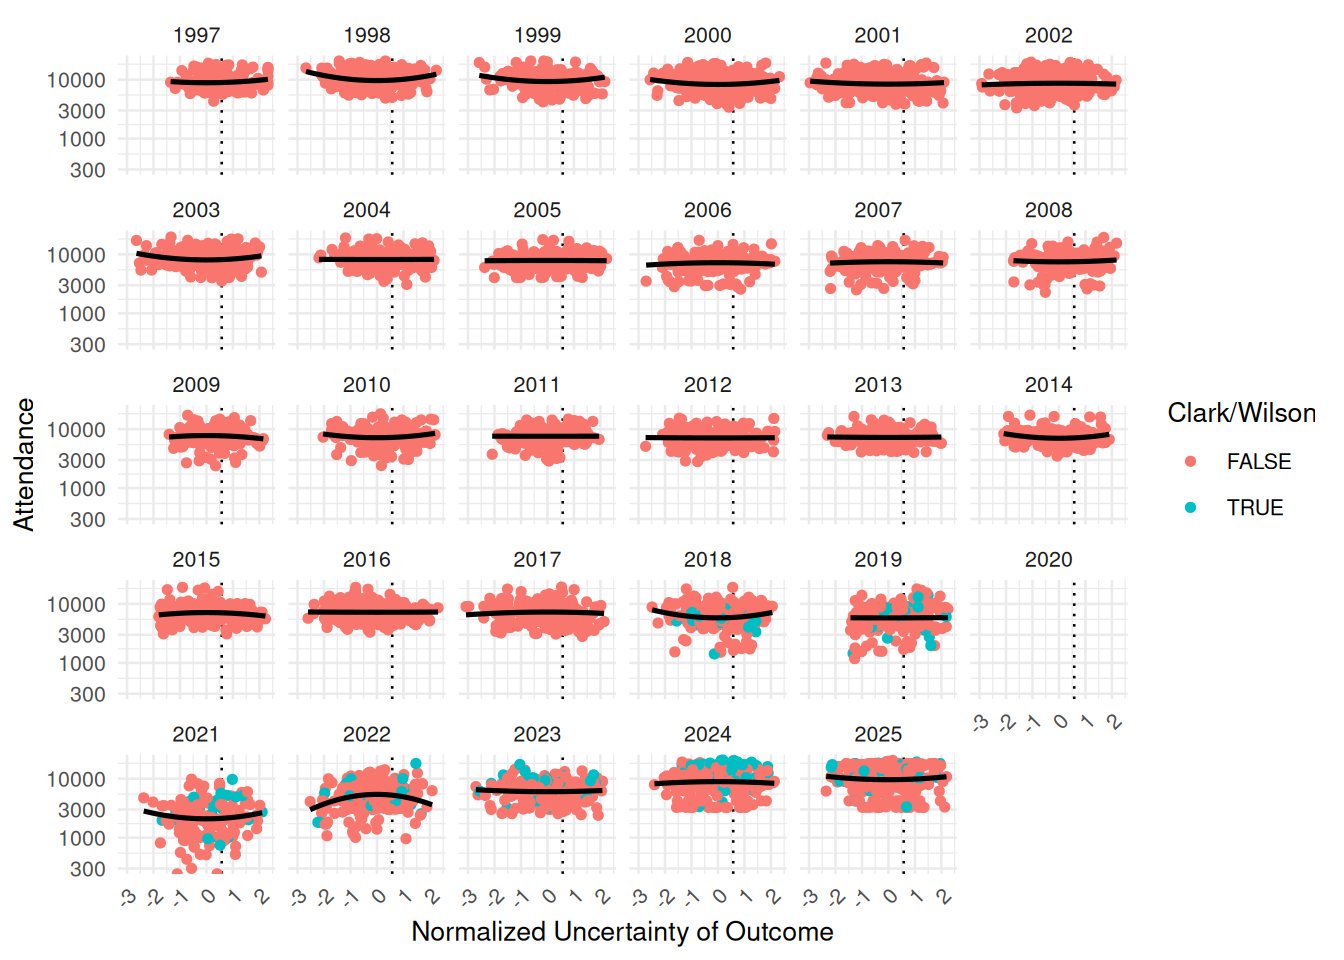

In [ ]:
plot_attend +
  aes(x = z2_uncertain_outcome) +
  scale_x_continuous("Normalized Uncertainty of Outcome") + 
  scale_y_log10("Attendance")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

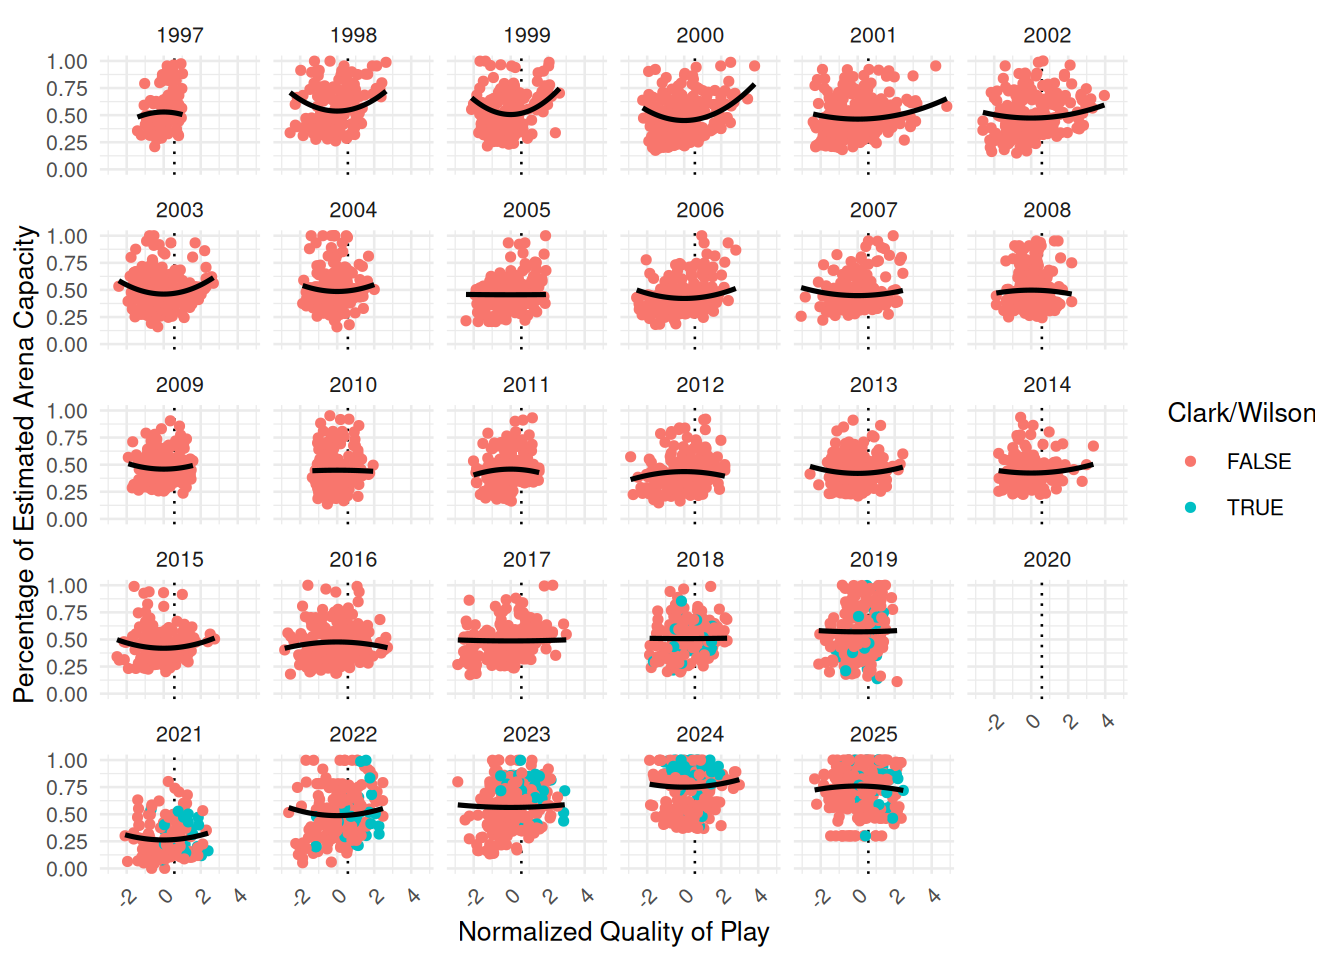

In [ ]:
plot_capacity +
  aes(x = z1_quality_of_play) + 
  scale_x_continuous("Normalized Quality of Play")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

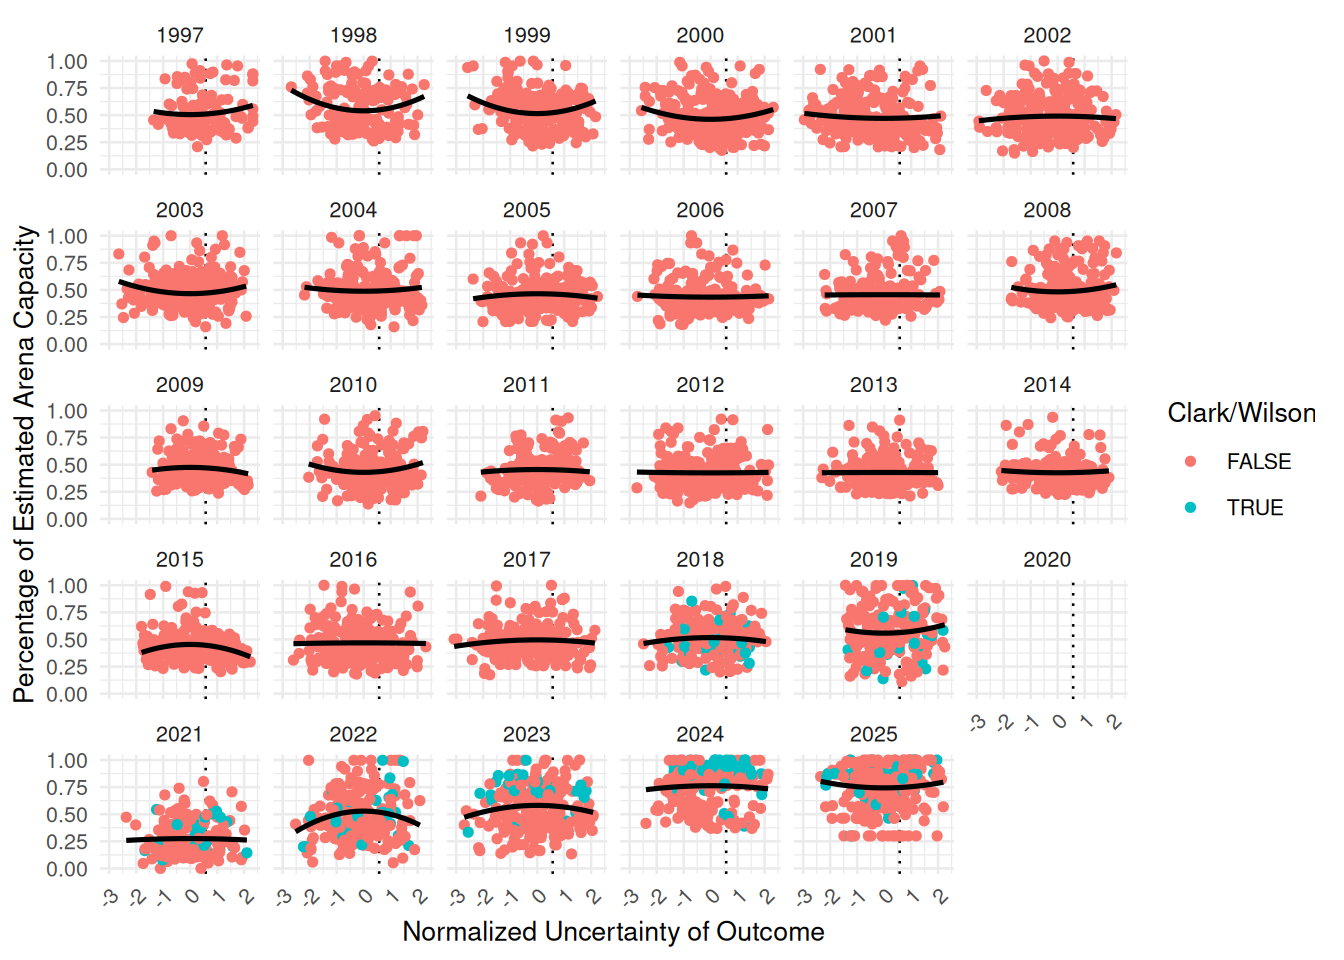

In [ ]:
plot_capacity +
  aes(x = z2_uncertain_outcome) +
  scale_x_continuous("Normalized Uncertainty of Outcome")

### Model fitting metrics for attendance model

In [ ]:
mod_attend |>
  broom::glance() |>
  bind_rows(.id = "model") |>
  knitr::kable(digits = 3)

  model     nobs   df.residual      logLik        AIC        BIC
  ------- ------ ------------- ----------- ---------- ----------
  1         5063          9991   -1283.677   2837.354   3718.865


In [ ]:
mod_attend |>
  anova() |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  ---------------------------------------------------------------------------------------
                                                Df X2 log Lik   Resid     Log Lik  Pr Chi
                                                         Diff      Df             
  ------------------------------------------- ---- ---------- ------- ----------- -------
  I(z1_quality_of_play)                          1    210.087   10018   -1474.428   0.000

  I(z2_uncertain_outcome)                        1      0.196   10018   -1305.246   0.658

  I(z3_loss_aversion)                            1    173.653   10018   -1463.765   0.000

  factor(name_current)                          12   1026.381   10003   -1796.867   0.000

  median_income                                  1     17.205    9992   -1292.279   0.000

  metro_pop                                      1      6.669    9992   -1287.011   0.010

  is_cc                                          1    245.851    9992   -1406.602   0.000

  is_aw                                          1      3.322    9992   -1285.338   0.068

  factor(season_id)                             26    774.641   10095   -1869.156   0.000

  as.character(wday(game_date, label = TRUE,     6    179.939    9997   -1373.646   0.000
  abbr = FALSE))                                                                  

  as.character(month(game_date, label = TRUE,    4    152.937    9995   -1360.145   0.000
  abbr = FALSE))                                                                  

  I(z1_quality_of_play):factor(season_id)       26    171.416   10017   -1369.385   0.000

  I(z2_uncertain_outcome):factor(season_id)     26     42.942   10017   -1305.148   0.020

  I(z3_loss_aversion):factor(season_id)         26    186.524   10017   -1376.939   0.000
  ---------------------------------------------------------------------------------------


### Model fitting metrics for percentage of arena capacity model

In [ ]:
mod_pct |>
  broom::glance() |>
  knitr::kable()

  ------------------------------------------------------------------------------------------
    null.deviance   df.null      logLik       AIC        BIC   deviance   df.residual   nobs
  --------------- --------- ----------- --------- ---------- ---------- ------------- ------
         841.2874      5062   -2977.425   6222.85   7097.831   473.3406          4929   5063

  ------------------------------------------------------------------------------------------


In [ ]:
mod_pct |>
  anova() |>
  broom::tidy() |>
  filter_out(str_detect(term, "NULL")) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  ------------------------------------------------------------------------------------------
  Term                                          Df   Deviance         Df    Residual P Value
                                                                Residual    Deviance 
  ------------------------------------------- ---- ---------- ---------- ----------- -------
  I(z1_quality_of_play)                          1     23.076       5061     818.212   0.000

  I(z2_uncertain_outcome)                        1      0.008       5060     818.203   0.927

  I(z3_loss_aversion)                            1      9.976       5059     808.227   0.002

  factor(name_current)                          12     97.666       5047     710.561   0.000

  median_income                                  1     80.763       5046     629.798   0.000

  metro_pop                                      1      2.846       5045     626.952   0.092

  is_cc                                          1     33.209       5044     593.743   0.000

  is_aw                                          1      3.128       5043     590.615   0.077

  factor(season_id)                             26     69.636       5017     520.980   0.000

  as.character(wday(game_date, label = TRUE,     6     15.048       5011     505.932   0.020
  abbr = FALSE))                                                                     

  as.character(month(game_date, label = TRUE,    4     12.826       5007     493.106   0.012
  abbr = FALSE))                                                                     

  I(z1_quality_of_play):factor(season_id)       26      5.860       4981     487.246   1.000

  I(z2_uncertain_outcome):factor(season_id)     26      3.613       4955     483.632   1.000

  I(z3_loss_aversion):factor(season_id)         26     10.292       4929     473.341   0.997
  ------------------------------------------------------------------------------------------
